In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import json
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\Users\Proprietaire\Desktop\Projet_perso\Projets\Revirement_politique_fr_gaza\projet_gaza


In [2]:
tweets_df = pd.read_parquet(DATA_DIR / "filtered" / "tweets_gaza.parquet")
interv_df = pd.read_parquet(DATA_DIR / "filtered" / "interventions_gaza.parquet")

print(f"Tweets Gaza: {len(tweets_df):,}")
print(f"Interventions Gaza: {len(interv_df):,}")
print(f"\nColonnes tweets: {list(tweets_df.columns)}")

Tweets Gaza: 11,735
Interventions Gaza: 1,705

Colonnes tweets: ['username', 'month_file', 'tweet_id', 'text', 'date_raw', 'date_parsed', 'retweets', 'likes', 'replies', 'quotes', 'is_retweet', 'is_reply', 'has_media', 'url', 'depute_name', 'groupe_politique', 'intervention_count', 'match_type', 'keyword_matches', 'match_confidence']


In [3]:
# Traiter les tweets
tweets_df["date"] = pd.to_datetime(tweets_df["date_parsed"])
tweets_df["year_month"] = tweets_df["date"].dt.to_period("M")
tweets_df["year_week"] = tweets_df["date"].dt.to_period("W")

# Traiter les interventions - utiliser sitting_date
if "sitting_date" in interv_df.columns:
    interv_df["date"] = pd.to_datetime(interv_df["sitting_date"])
    interv_df["year_month"] = interv_df["date"].dt.to_period("M")
elif "intervention_date" in interv_df.columns:
    interv_df["date"] = pd.to_datetime(interv_df["intervention_date"])
    interv_df["year_month"] = interv_df["date"].dt.to_period("M")
elif "date" in interv_df.columns:
    interv_df["date"] = pd.to_datetime(interv_df["date"])
    interv_df["year_month"] = interv_df["date"].dt.to_period("M")
else:
    print("ATTENTION: Aucune colonne de date trouvée dans interv_df")
    print(f"Colonnes disponibles: {list(interv_df.columns)}")

print(f"Tweets - Periode: {tweets_df['date'].min()} a {tweets_df['date'].max()}")
print(f"Interventions - Periode: {interv_df['date'].min()} a {interv_df['date'].max()}")

Tweets - Periode: 2023-01-01 14:44:00 a 2026-01-06 17:00:00
Interventions - Periode: 2023-01-12 00:00:00 a 2025-12-18 00:00:00


In [4]:
events = {
    "2023-10-07": "7 octobre",
    "2023-10-27": "Offensive terrestre",
    "2024-01-26": "Ordonnance CIJ",
    "2024-05-06": "Offensive Rafah",
    "2024-05-28": "Reconnaissance Palestine (ES/IE/NO)",
    "2024-11-21": "Mandats CPI",
    "2025-01-15": "Cessez-le-feu",
}


def add_event_lines(ax, events_dict, ymax=None):
    for date_str, label in events_dict.items():
        date = pd.to_datetime(date_str)
        ax.axvline(x=date, color="red", linestyle="--", alpha=0.7, linewidth=1)
        if ymax:
            ax.text(
                date, ymax * 0.95, label, rotation=90, va="top", ha="right", fontsize=8
            )

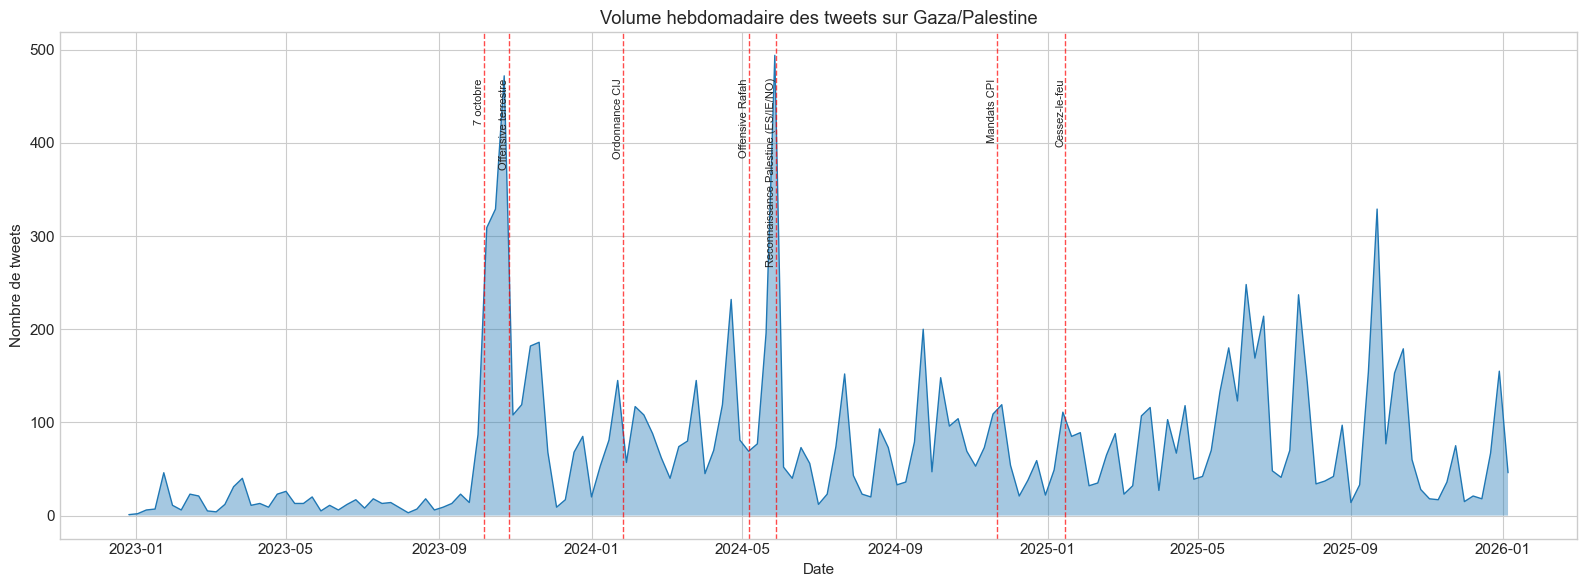

In [5]:
tweets_weekly = tweets_df.groupby("year_week").size()
tweets_weekly.index = tweets_weekly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(tweets_weekly.index, tweets_weekly.values, alpha=0.4)
ax.plot(tweets_weekly.index, tweets_weekly.values, linewidth=1)

add_event_lines(ax, events, tweets_weekly.max())

ax.set_title("Volume hebdomadaire des tweets sur Gaza/Palestine")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de tweets")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "tweets_temporal.png", dpi=150)
plt.show()

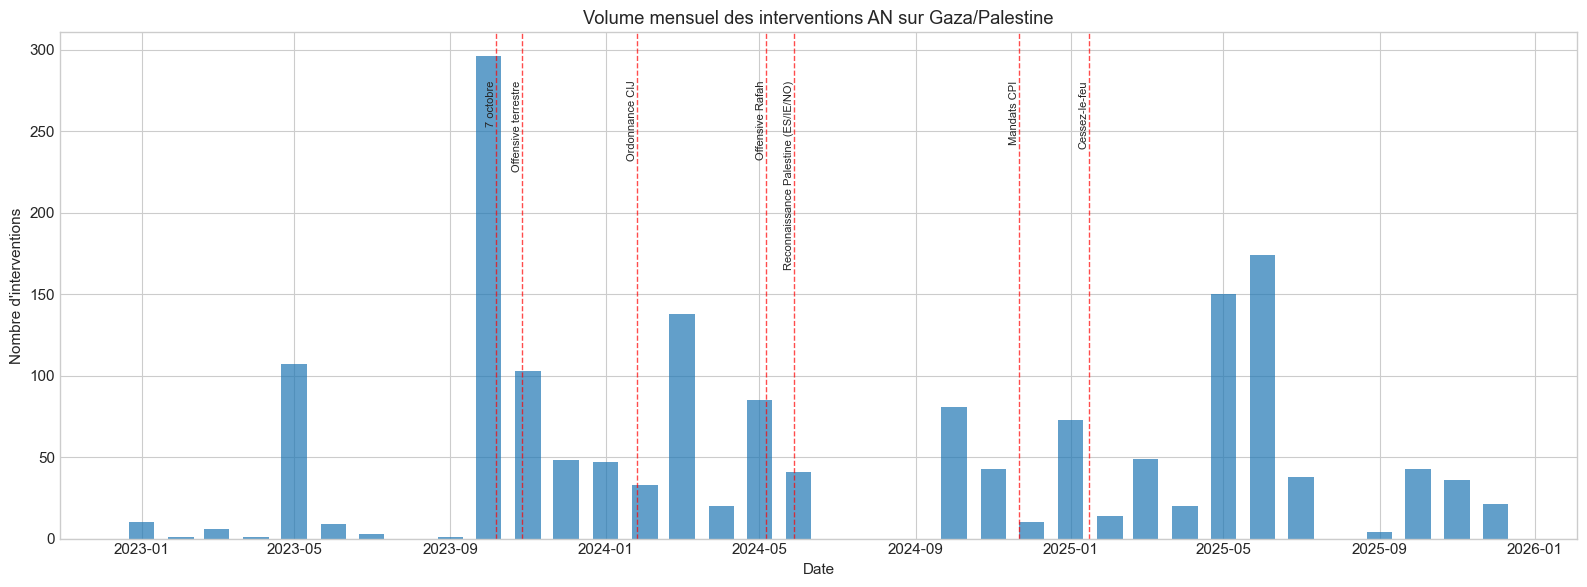

In [6]:
interv_monthly = interv_df.groupby("year_month").size()
interv_monthly.index = interv_monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(interv_monthly.index, interv_monthly.values, width=20, alpha=0.7)

add_event_lines(ax, events, interv_monthly.max())

ax.set_title("Volume mensuel des interventions AN sur Gaza/Palestine")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre d'interventions")
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "outputs" / "figures" / "interventions_temporal.png", dpi=150
)
plt.show()

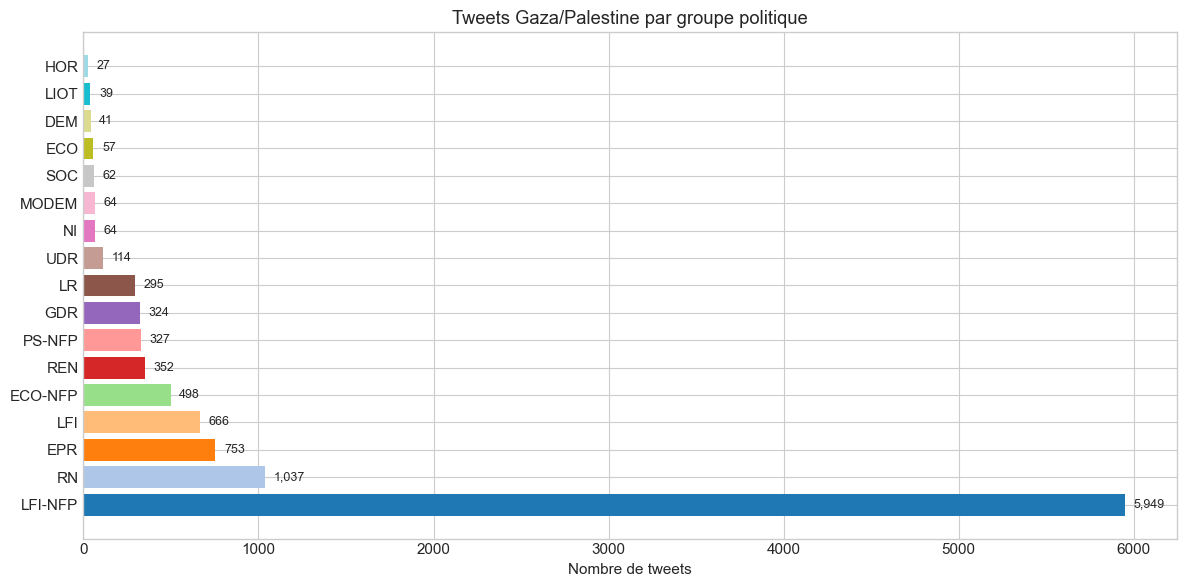

In [7]:
if "groupe_politique" in tweets_df.columns:
    group_counts = tweets_df["groupe_politique"].value_counts()

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.tab20(np.linspace(0, 1, len(group_counts)))
    bars = ax.barh(group_counts.index, group_counts.values, color=colors)

    for bar, count in zip(bars, group_counts.values):
        ax.text(
            bar.get_width() + 50,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,}",
            va="center",
            fontsize=9,
        )

    ax.set_title("Tweets Gaza/Palestine par groupe politique")
    ax.set_xlabel("Nombre de tweets")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "tweets_by_group.png", dpi=150)
    plt.show()

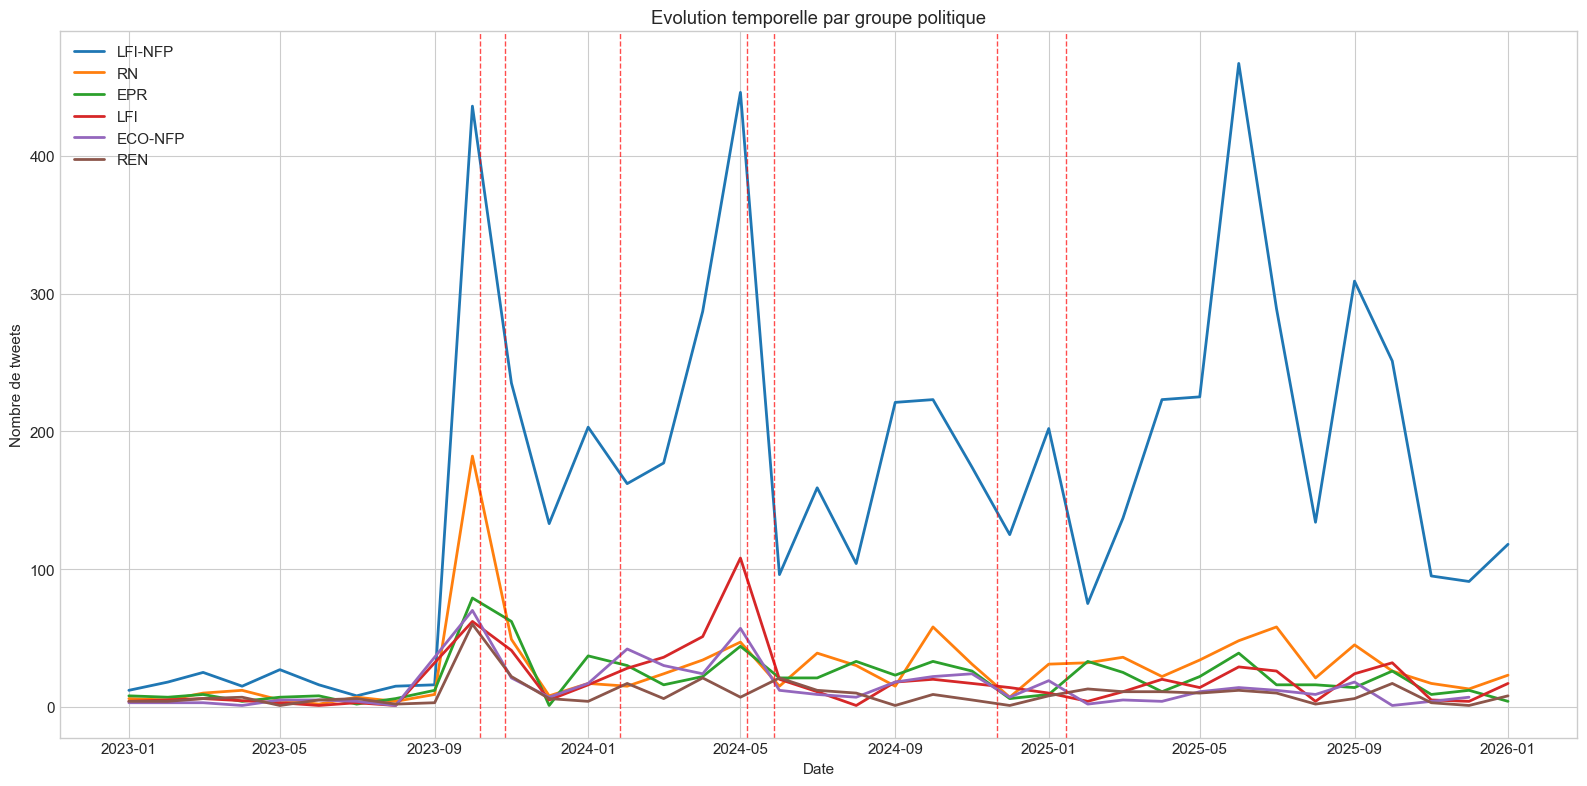

In [8]:
if "groupe_politique" in tweets_df.columns:
    top_groups = tweets_df["groupe_politique"].value_counts().head(6).index.tolist()

    fig, ax = plt.subplots(figsize=(16, 8))

    for group in top_groups:
        group_data = tweets_df[tweets_df["groupe_politique"] == group]
        monthly = group_data.groupby("year_month").size()
        monthly.index = monthly.index.to_timestamp()
        ax.plot(monthly.index, monthly.values, label=group, linewidth=2)

    add_event_lines(ax, events)

    ax.set_title("Evolution temporelle par groupe politique")
    ax.set_xlabel("Date")
    ax.set_ylabel("Nombre de tweets")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(
        PROJECT_ROOT / "outputs" / "figures" / "tweets_evolution_by_group.png", dpi=150
    )
    plt.show()

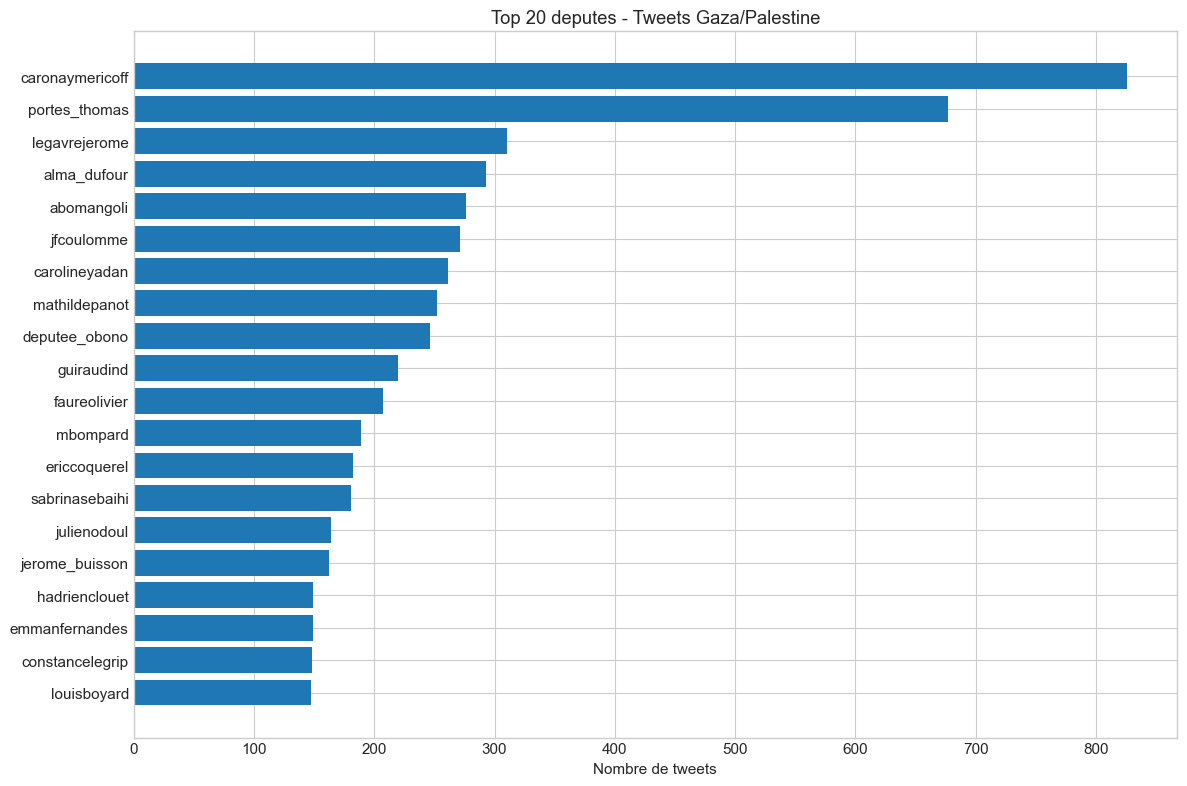

In [9]:
if "username" in tweets_df.columns:
    top_users = tweets_df["username"].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(top_users.index[::-1], top_users.values[::-1])
    ax.set_title("Top 20 deputes - Tweets Gaza/Palestine")
    ax.set_xlabel("Nombre de tweets")
    plt.tight_layout()
    plt.savefig(
        PROJECT_ROOT / "outputs" / "figures" / "top_deputes_tweets.png", dpi=150
    )
    plt.show()

Total mots-cles uniques: 106
Top 10: [('israel', 4584), ('gaza', 3771), ('palestinien', 2490), ('israelien', 2191), ('genocide', 1964), ('hamas', 1607), ('palestine', 1501), ('palestiniens', 1206), ('massacre', 1038), ('otage', 1033)]


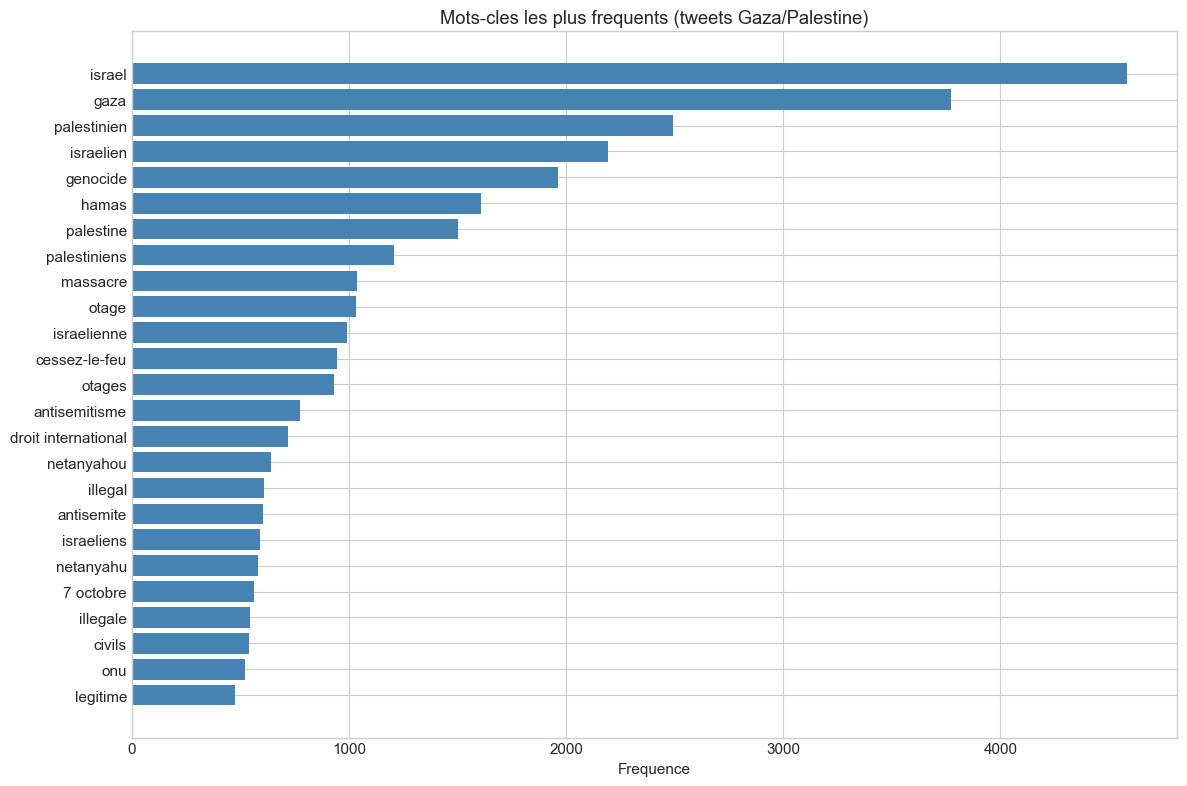

In [10]:
from collections import Counter
import numpy as np


def extract_keywords(df, col="keyword_matches"):
    """Extrait les mots-cles (gere list, numpy array, string)."""
    all_kw = []
    for matches in df[col].dropna():
        if isinstance(matches, np.ndarray):
            all_kw.extend(matches.tolist())
        elif isinstance(matches, list):
            all_kw.extend(matches)
        elif isinstance(matches, str):
            # Essayer de parser si c'est une string representant une liste
            try:
                parsed = eval(matches)
                if isinstance(parsed, (list, tuple)):
                    all_kw.extend(parsed)
            except:
                pass
    return Counter(all_kw)


# Extraire et afficher
kw_counts = extract_keywords(tweets_df)
top_kw = kw_counts.most_common(25)

print(f"Total mots-cles uniques: {len(kw_counts)}")
print(f"Top 10: {top_kw[:10]}")

if top_kw:
    fig, ax = plt.subplots(figsize=(12, 8))
    keywords, counts = zip(*top_kw)
    ax.barh(keywords[::-1], counts[::-1], color="steelblue")
    ax.set_title("Mots-cles les plus frequents (tweets Gaza/Palestine)")
    ax.set_xlabel("Frequence")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "top_keywords.png", dpi=150)
    plt.show()

In [11]:
print("=" * 60)
print("STATISTIQUES DU CORPUS GAZA/PALESTINE")
print("=" * 60)

print(f"\nTWEETS")
print(f"  Total: {len(tweets_df):,}")
print(f"  Utilisateurs uniques: {tweets_df['username'].nunique()}")
print(f"  Periode: {tweets_df['date'].min().date()} - {tweets_df['date'].max().date()}")

if "groupe_politique" in tweets_df.columns:
    print(f"\n  Par groupe politique:")
    for group, count in tweets_df["groupe_politique"].value_counts().head(8).items():
        print(f"    {group}: {count:,}")

print(f"\nINTERVENTIONS AN")
print(f"  Total: {len(interv_df):,}")
if "depute_name" in interv_df.columns:
    print(f"  Deputes uniques: {interv_df['depute_name'].nunique()}")
print(f"  Periode: {interv_df['date'].min().date()} - {interv_df['date'].max().date()}")

STATISTIQUES DU CORPUS GAZA/PALESTINE

TWEETS
  Total: 11,735
  Utilisateurs uniques: 264
  Periode: 2023-01-01 - 2026-01-06

  Par groupe politique:
    LFI-NFP: 5,949
    RN: 1,037
    EPR: 753
    LFI: 666
    ECO-NFP: 498
    REN: 352
    PS-NFP: 327
    GDR: 324

INTERVENTIONS AN
  Total: 1,705
  Periode: 2023-01-12 - 2025-12-18


_______________________________

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# Configuration
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

PROJECT_ROOT = Path.cwd()
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Evenements cles
EVENTS = {
    "7 octobre": "2023-10-07",
    "Offensive terrestre": "2023-10-27",
    "Ordonnance CIJ": "2024-01-26",
    "Offensive Rafah": "2024-05-06",
    "Reconnaissance Palestine": "2024-05-28",
    "Mandats CPI": "2024-11-21",
    "Cessez-le-feu": "2025-01-15",
}

print("Configuration chargee")

Configuration chargee


In [13]:
# Charger les donnees
tweets_df = pd.read_parquet(PROJECT_ROOT / "data" / "filtered" / "tweets_gaza.parquet")
interv_df = pd.read_parquet(
    PROJECT_ROOT / "data" / "filtered" / "interventions_gaza.parquet"
)

# Traiter les dates
tweets_df["date"] = pd.to_datetime(tweets_df["date_parsed"])
tweets_df["year_month"] = tweets_df["date"].dt.to_period("M")
tweets_df["year_week"] = tweets_df["date"].dt.to_period("W")
tweets_df["day_of_week"] = tweets_df["date"].dt.day_name()
tweets_df["hour"] = tweets_df["date"].dt.hour

if "sitting_date" in interv_df.columns:
    interv_df["date"] = pd.to_datetime(interv_df["sitting_date"])
elif "intervention_date" in interv_df.columns:
    interv_df["date"] = pd.to_datetime(interv_df["intervention_date"])
interv_df["year_month"] = interv_df["date"].dt.to_period("M")


# Normaliser les groupes politiques
def normalize_group(g):
    if pd.isna(g):
        return "Inconnu"
    g = str(g).upper()
    if "LFI" in g or "NUPES" in g:
        return "LFI/NUPES"
    if "RN" in g:
        return "RN"
    if "LR" in g:
        return "LR"
    if "PS" in g or "SOC" in g:
        return "PS/SOC"
    if "ECO" in g or "VERT" in g:
        return "EELV"
    if "REN" in g or "LREM" in g or "EPR" in g:
        return "Renaissance"
    if "GDR" in g or "COM" in g:
        return "GDR"
    if "DEM" in g or "MODEM" in g:
        return "MoDem"
    if "HOR" in g:
        return "Horizons"
    if "LIOT" in g:
        return "LIOT"
    return g


tweets_df["groupe_norm"] = tweets_df["groupe_politique"].apply(normalize_group)
interv_df["groupe_norm"] = interv_df["matched_group"].apply(normalize_group)

print("=" * 60)
print("CORPUS CHARGE")
print("=" * 60)
print(f"\nTWEETS: {len(tweets_df):,}")
print(
    f"  Periode: {tweets_df['date'].min().date()} -> {tweets_df['date'].max().date()}"
)
print(f"  Utilisateurs: {tweets_df['username'].nunique()}")
print(f"  Groupes: {tweets_df['groupe_norm'].nunique()}")

print(f"\nINTERVENTIONS AN: {len(interv_df):,}")
print(
    f"  Periode: {interv_df['date'].min().date()} -> {interv_df['date'].max().date()}"
)
print(f"  Orateurs: {interv_df['speaker_name'].nunique()}")

CORPUS CHARGE

TWEETS: 11,735
  Periode: 2023-01-01 -> 2026-01-06
  Utilisateurs: 264
  Groupes: 13

INTERVENTIONS AN: 1,705
  Periode: 2023-01-12 -> 2025-12-18
  Orateurs: 349


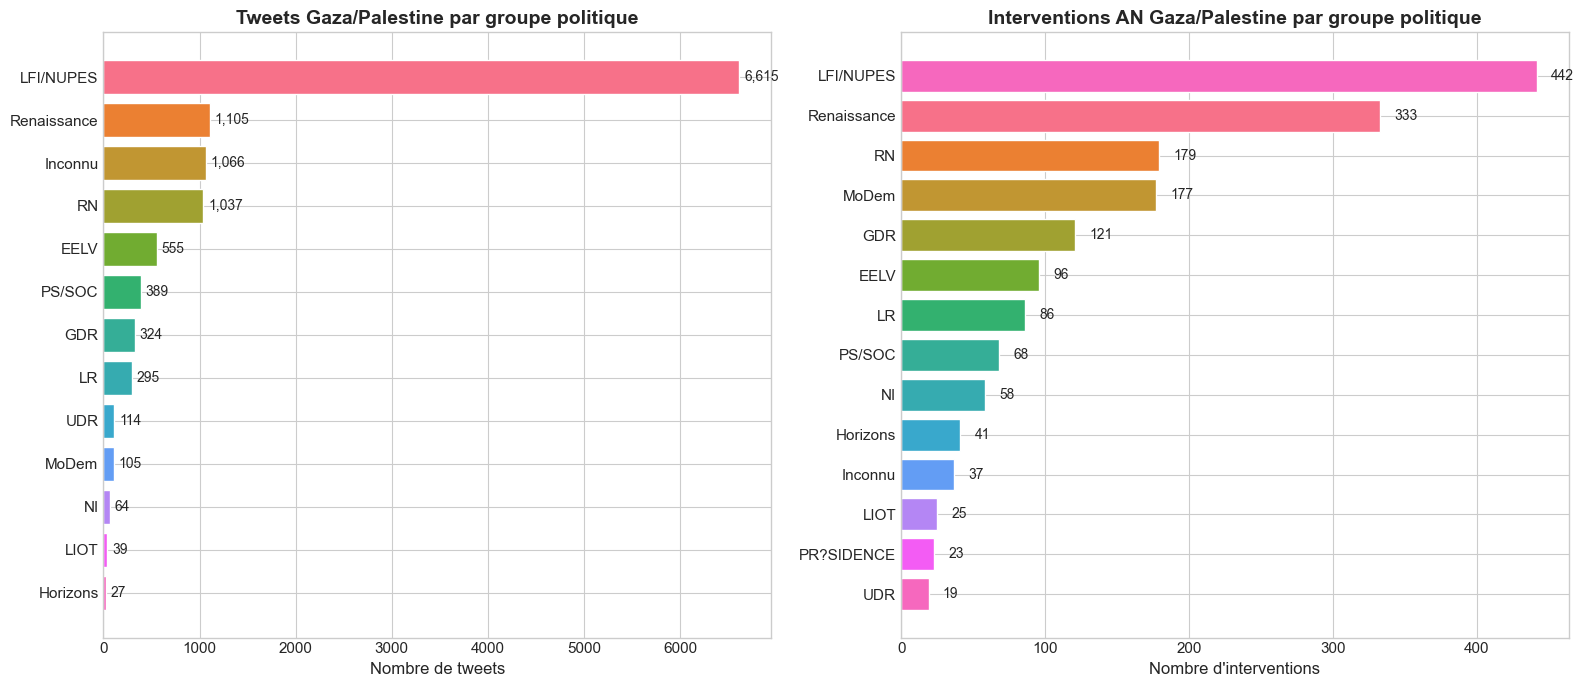


Ratio tweets/interventions par groupe:
  LFI/NUPES: 15.0x
  Renaissance: 3.3x
  Inconnu: 28.8x
  RN: 5.8x
  EELV: 5.8x
  PS/SOC: 5.7x
  GDR: 2.7x
  LR: 3.4x
  UDR: 6.0x
  MoDem: 0.6x
  NI: 1.1x
  LIOT: 1.6x
  Horizons: 0.7x


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Tweets par groupe
tweets_by_group = tweets_df["groupe_norm"].value_counts()
colors = sns.color_palette("husl", len(tweets_by_group))
bars1 = axes[0].barh(
    tweets_by_group.index[::-1], tweets_by_group.values[::-1], color=colors[::-1]
)
axes[0].set_title("Tweets Gaza/Palestine par groupe politique", fontweight="bold")
axes[0].set_xlabel("Nombre de tweets")
for bar, val in zip(bars1, tweets_by_group.values[::-1]):
    axes[0].text(
        val + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=10,
    )

# Interventions par groupe
interv_by_group = interv_df["groupe_norm"].value_counts()
bars2 = axes[1].barh(
    interv_by_group.index[::-1], interv_by_group.values[::-1], color=colors[::-1]
)
axes[1].set_title(
    "Interventions AN Gaza/Palestine par groupe politique", fontweight="bold"
)
axes[1].set_xlabel("Nombre d'interventions")
for bar, val in zip(bars2, interv_by_group.values[::-1]):
    axes[1].text(
        val + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribution_groupes.png", dpi=150, bbox_inches="tight")
plt.show()

# Stats
print("\nRatio tweets/interventions par groupe:")
for g in tweets_by_group.index:
    t = tweets_by_group.get(g, 0)
    i = interv_by_group.get(g, 1)
    ratio = t / i if i > 0 else 0
    print(f"  {g}: {ratio:.1f}x")

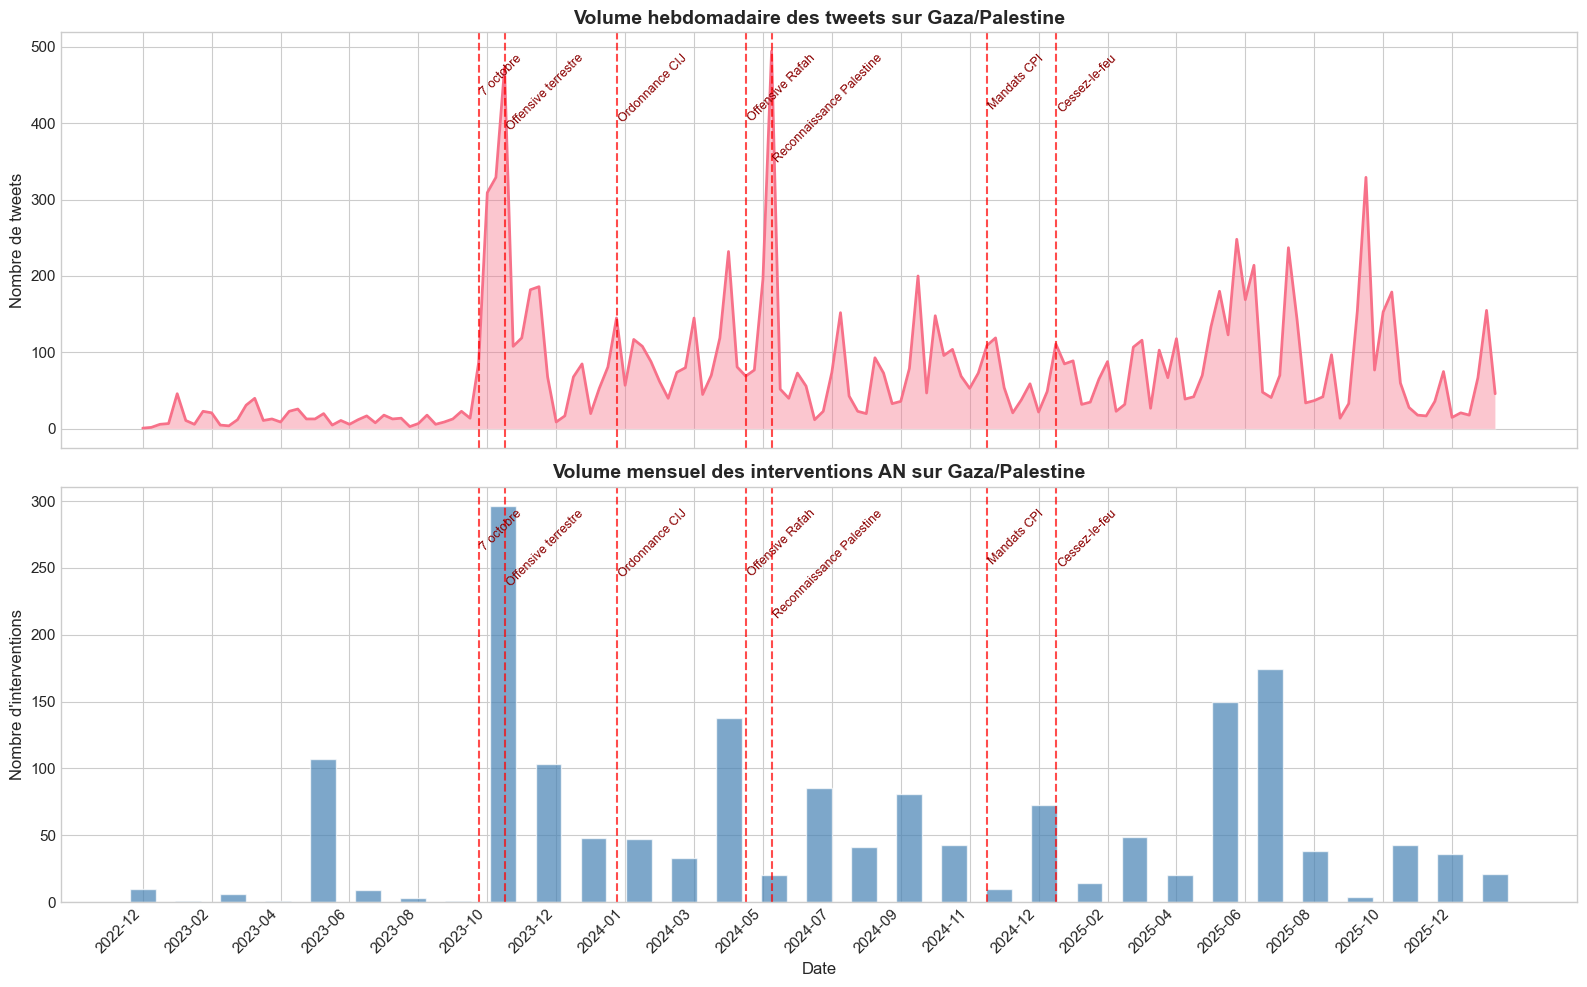

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Tweets hebdomadaires
tweets_weekly = tweets_df.groupby("year_week").size()
weeks = [str(w) for w in tweets_weekly.index]
x_weeks = range(len(weeks))
axes[0].fill_between(x_weeks, tweets_weekly.values, alpha=0.4)
axes[0].plot(x_weeks, tweets_weekly.values, linewidth=2)
axes[0].set_title(
    "Volume hebdomadaire des tweets sur Gaza/Palestine", fontweight="bold"
)
axes[0].set_ylabel("Nombre de tweets")

# Interventions mensuelles
interv_monthly = interv_df.groupby("year_month").size()
months = [str(m) for m in interv_monthly.index]
x_months = np.linspace(0, len(weeks) - 1, len(months))
axes[1].bar(x_months, interv_monthly.values, width=3, alpha=0.7, color="steelblue")
axes[1].set_title(
    "Volume mensuel des interventions AN sur Gaza/Palestine", fontweight="bold"
)
axes[1].set_ylabel("Nombre d'interventions")
axes[1].set_xlabel("Date")

# Ajouter les evenements
for ax in axes:
    for event_name, event_date in EVENTS.items():
        event_dt = pd.to_datetime(event_date)
        # Trouver la position sur l'axe x
        for i, w in enumerate(tweets_weekly.index):
            if event_dt >= w.start_time and event_dt <= w.end_time:
                ax.axvline(x=i, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
                ax.text(
                    i,
                    ax.get_ylim()[1] * 0.95,
                    event_name,
                    rotation=45,
                    fontsize=9,
                    ha="left",
                    va="top",
                    color="darkred",
                )
                break

# Formater l'axe x
tick_positions = list(range(0, len(weeks), 8))
tick_labels = [weeks[i][:7] for i in tick_positions]
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "evolution_temporelle.png", dpi=150, bbox_inches="tight")
plt.show()

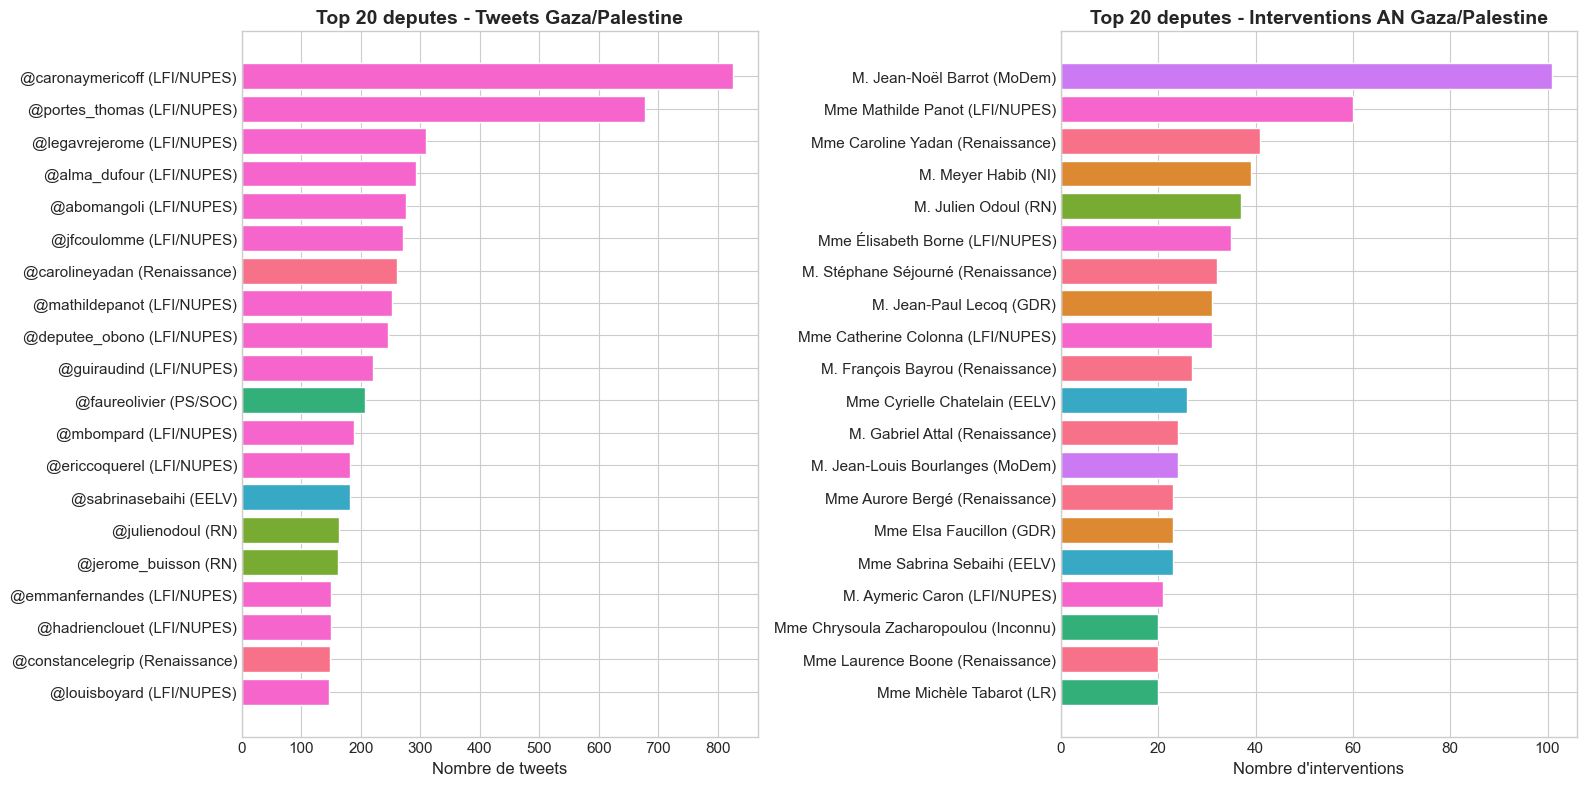

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 Twitter
top_twitter = (
    tweets_df.groupby(["username", "groupe_norm"]).size().reset_index(name="count")
)
top_twitter = top_twitter.nlargest(20, "count")
colors_tw = [
    sns.color_palette("husl", 10)[hash(g) % 10] for g in top_twitter["groupe_norm"]
]
bars1 = axes[0].barh(
    range(len(top_twitter)), top_twitter["count"].values, color=colors_tw
)
axes[0].set_yticks(range(len(top_twitter)))
axes[0].set_yticklabels(
    [f"@{u} ({g})" for u, g in zip(top_twitter["username"], top_twitter["groupe_norm"])]
)
axes[0].invert_yaxis()
axes[0].set_title("Top 20 deputes - Tweets Gaza/Palestine", fontweight="bold")
axes[0].set_xlabel("Nombre de tweets")

# Top 20 AN
top_an = (
    interv_df.groupby(["speaker_name", "groupe_norm"]).size().reset_index(name="count")
)
top_an = top_an.nlargest(20, "count")
colors_an = [sns.color_palette("husl", 10)[hash(g) % 10] for g in top_an["groupe_norm"]]
bars2 = axes[1].barh(range(len(top_an)), top_an["count"].values, color=colors_an)
axes[1].set_yticks(range(len(top_an)))
axes[1].set_yticklabels(
    [f"{n} ({g})" for n, g in zip(top_an["speaker_name"], top_an["groupe_norm"])]
)
axes[1].invert_yaxis()
axes[1].set_title("Top 20 deputes - Interventions AN Gaza/Palestine", fontweight="bold")
axes[1].set_xlabel("Nombre d'interventions")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_deputes.png", dpi=150, bbox_inches="tight")
plt.show()

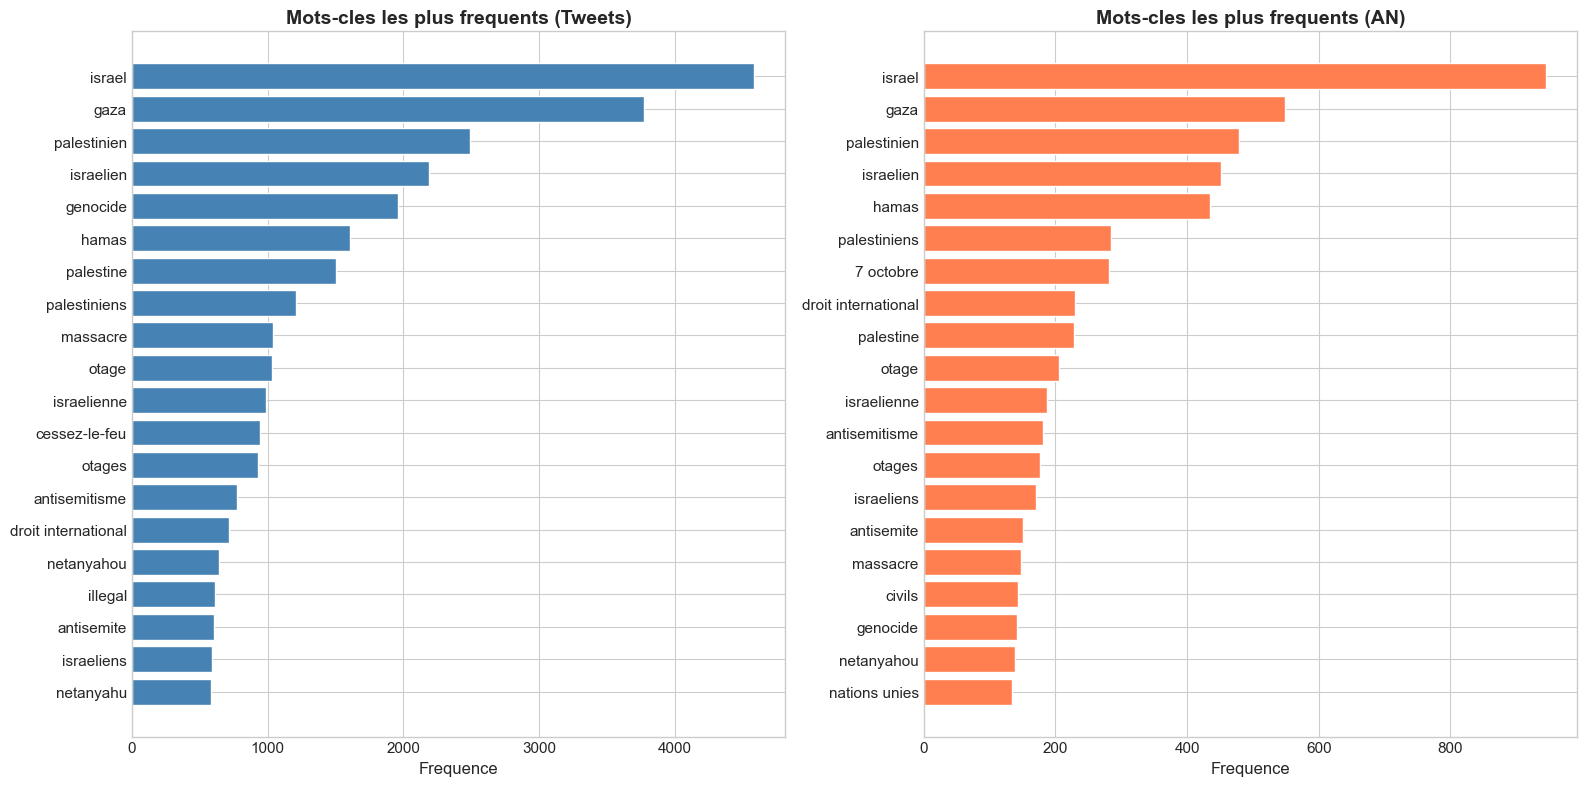


Total mots-cles uniques tweets: 106
Total mots-cles uniques AN: 94


In [17]:
def extract_keywords(df, col="keyword_matches"):
    all_kw = []
    for matches in df[col].dropna():
        if isinstance(matches, np.ndarray):
            all_kw.extend(matches.tolist())
        elif isinstance(matches, list):
            all_kw.extend(matches)
        elif isinstance(matches, str):
            try:
                parsed = eval(matches)
                if isinstance(parsed, (list, tuple)):
                    all_kw.extend(parsed)
            except:
                pass
    return Counter(all_kw)


fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Keywords tweets
kw_tweets = extract_keywords(tweets_df)
top_kw_tweets = kw_tweets.most_common(20)
if top_kw_tweets:
    kw, counts = zip(*top_kw_tweets)
    axes[0].barh(kw[::-1], counts[::-1], color="steelblue")
    axes[0].set_title("Mots-cles les plus frequents (Tweets)", fontweight="bold")
    axes[0].set_xlabel("Frequence")

# Keywords interventions
if "keyword_matches_new" in interv_df.columns:
    kw_interv = extract_keywords(interv_df, "keyword_matches_new")
else:
    kw_interv = extract_keywords(interv_df, "keyword_matches")
top_kw_interv = kw_interv.most_common(20)
if top_kw_interv:
    kw, counts = zip(*top_kw_interv)
    axes[1].barh(kw[::-1], counts[::-1], color="coral")
    axes[1].set_title("Mots-cles les plus frequents (AN)", fontweight="bold")
    axes[1].set_xlabel("Frequence")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "keywords_frequents.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal mots-cles uniques tweets: {len(kw_tweets)}")
print(f"Total mots-cles uniques AN: {len(kw_interv)}")

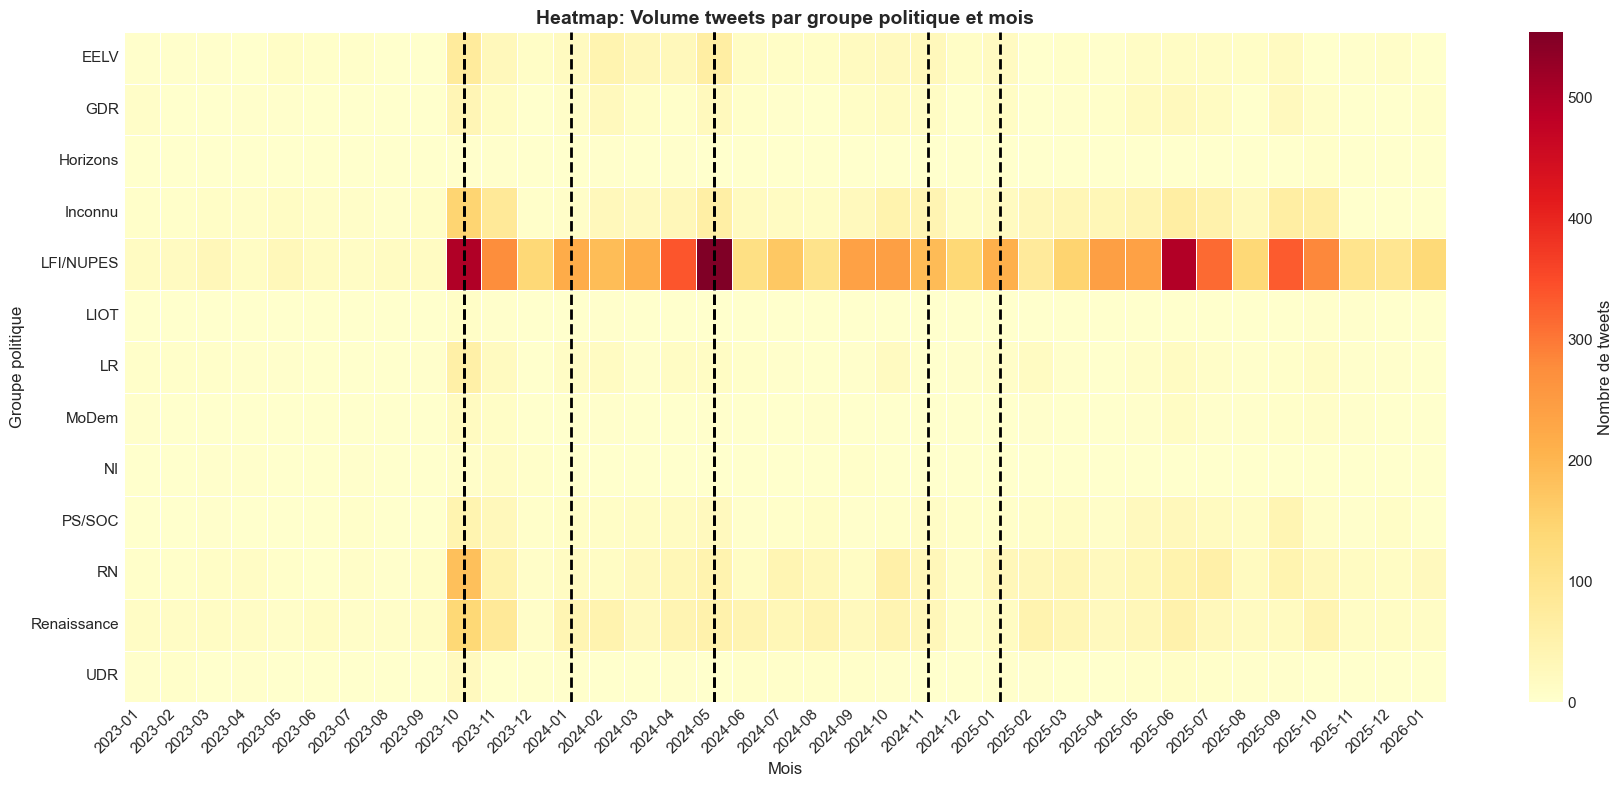

In [18]:
# Creer une matrice groupe x mois
tweets_pivot = (
    tweets_df.groupby(["year_month", "groupe_norm"]).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    tweets_pivot.T,
    cmap="YlOrRd",
    annot=False,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Nombre de tweets"},
    ax=ax,
)

# Formater les labels
month_labels = [str(m)[:7] for m in tweets_pivot.index]
ax.set_xticklabels(month_labels, rotation=45, ha="right")
ax.set_title(
    "Heatmap: Volume tweets par groupe politique et mois",
    fontweight="bold",
    fontsize=14,
)
ax.set_xlabel("Mois")
ax.set_ylabel("Groupe politique")

# Marquer les evenements
for event_name, event_date in EVENTS.items():
    event_period = pd.to_datetime(event_date).to_period("M")
    if event_period in tweets_pivot.index:
        idx = list(tweets_pivot.index).index(event_period)
        ax.axvline(x=idx + 0.5, color="black", linestyle="--", linewidth=2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "heatmap_groupe_mois.png", dpi=150, bbox_inches="tight")
plt.show()

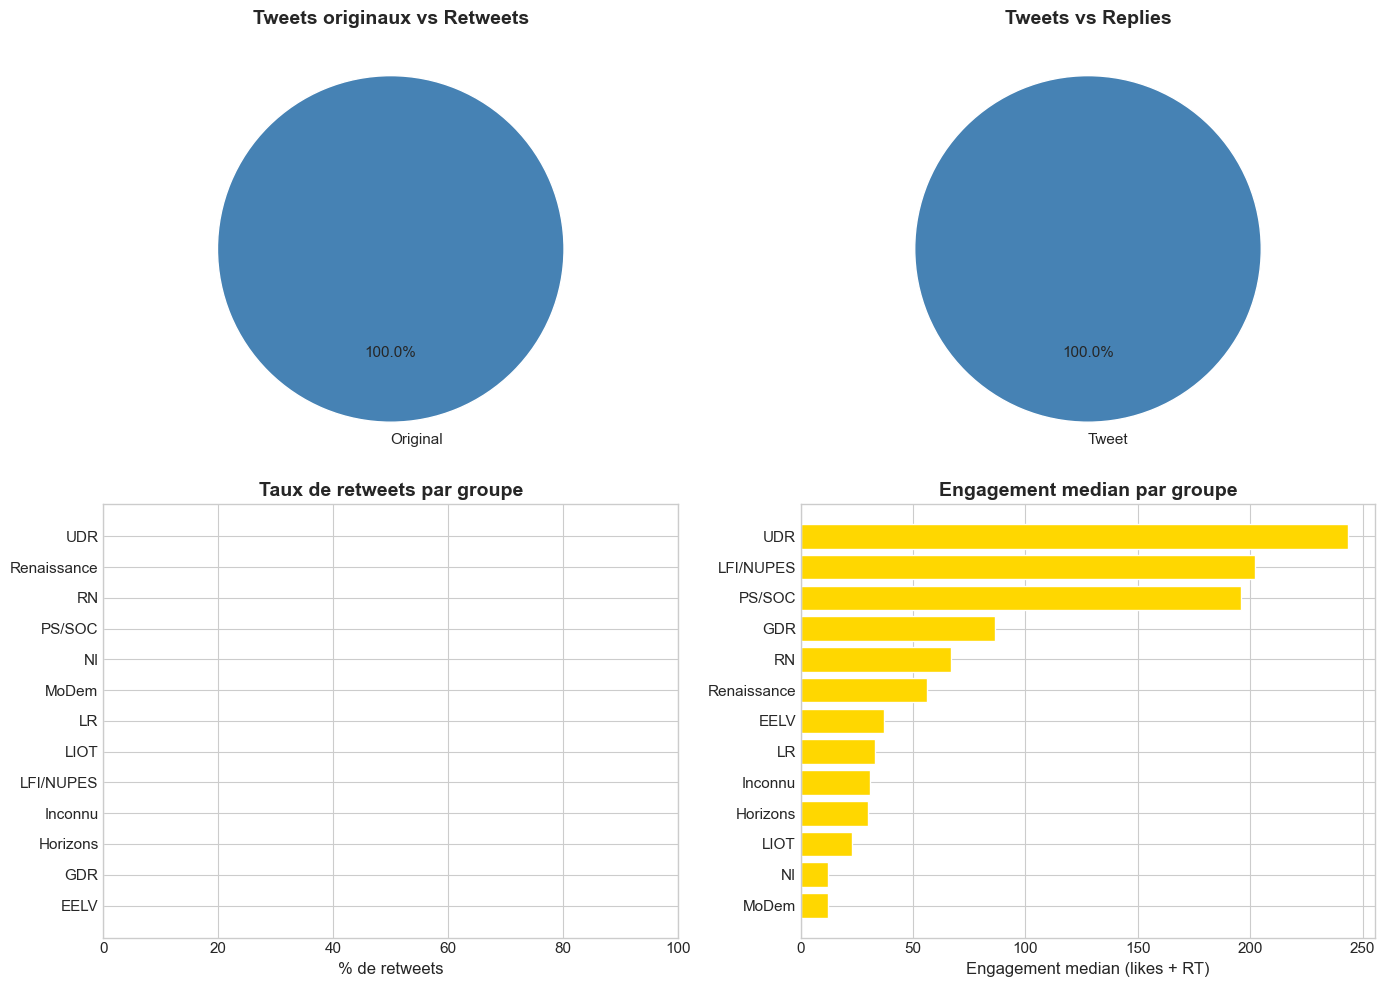


Statistiques engagement:
Likes - min: 0, max: 999, median: 29.0
Retweets - min: 0, max: 999, median: 28.0
Engagement - median: 109.0


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Creer la colonne engagement d'abord
tweets_df["engagement"] = tweets_df["likes"].fillna(0) + tweets_df["retweets"].fillna(0)

# Distribution RT vs original - gerer les NaN et valeurs multiples
is_rt = tweets_df["is_retweet"].fillna(False).astype(bool)
rt_counts = is_rt.value_counts()
labels_rt = ["Original" if not k else "Retweet" for k in rt_counts.index]
axes[0, 0].pie(
    rt_counts.values,
    labels=labels_rt,
    autopct="%1.1f%%",
    colors=["steelblue", "lightcoral"][: len(rt_counts)],
    startangle=90,
)
axes[0, 0].set_title("Tweets originaux vs Retweets", fontweight="bold")

# Distribution Reply vs non-reply
is_reply = tweets_df["is_reply"].fillna(False).astype(bool)
reply_counts = is_reply.value_counts()
labels_reply = ["Tweet" if not k else "Reply" for k in reply_counts.index]
axes[0, 1].pie(
    reply_counts.values,
    labels=labels_reply,
    autopct="%1.1f%%",
    colors=["steelblue", "lightgreen"][: len(reply_counts)],
    startangle=90,
)
axes[0, 1].set_title("Tweets vs Replies", fontweight="bold")

# RT par groupe
rt_by_group = tweets_df.groupby("groupe_norm")["is_retweet"].apply(
    lambda x: x.fillna(False).mean() * 100
)
rt_by_group = rt_by_group.sort_values(ascending=True)
axes[1, 0].barh(rt_by_group.index, rt_by_group.values, color="lightcoral")
axes[1, 0].set_xlabel("% de retweets")
axes[1, 0].set_title("Taux de retweets par groupe", fontweight="bold")
axes[1, 0].set_xlim(0, 100)

# Engagement moyen (likes + retweets)
engagement_by_group = tweets_df.groupby("groupe_norm")["engagement"].median()
engagement_by_group = engagement_by_group.sort_values(ascending=True)
axes[1, 1].barh(engagement_by_group.index, engagement_by_group.values, color="gold")
axes[1, 1].set_xlabel("Engagement median (likes + RT)")
axes[1, 1].set_title("Engagement median par groupe", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "analyse_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nStatistiques engagement:")
print(
    f"Likes - min: {tweets_df['likes'].min()}, max: {tweets_df['likes'].max()}, median: {tweets_df['likes'].median()}"
)
print(
    f"Retweets - min: {tweets_df['retweets'].min()}, max: {tweets_df['retweets'].max()}, median: {tweets_df['retweets'].median()}"
)
print(f"Engagement - median: {tweets_df['engagement'].median()}")

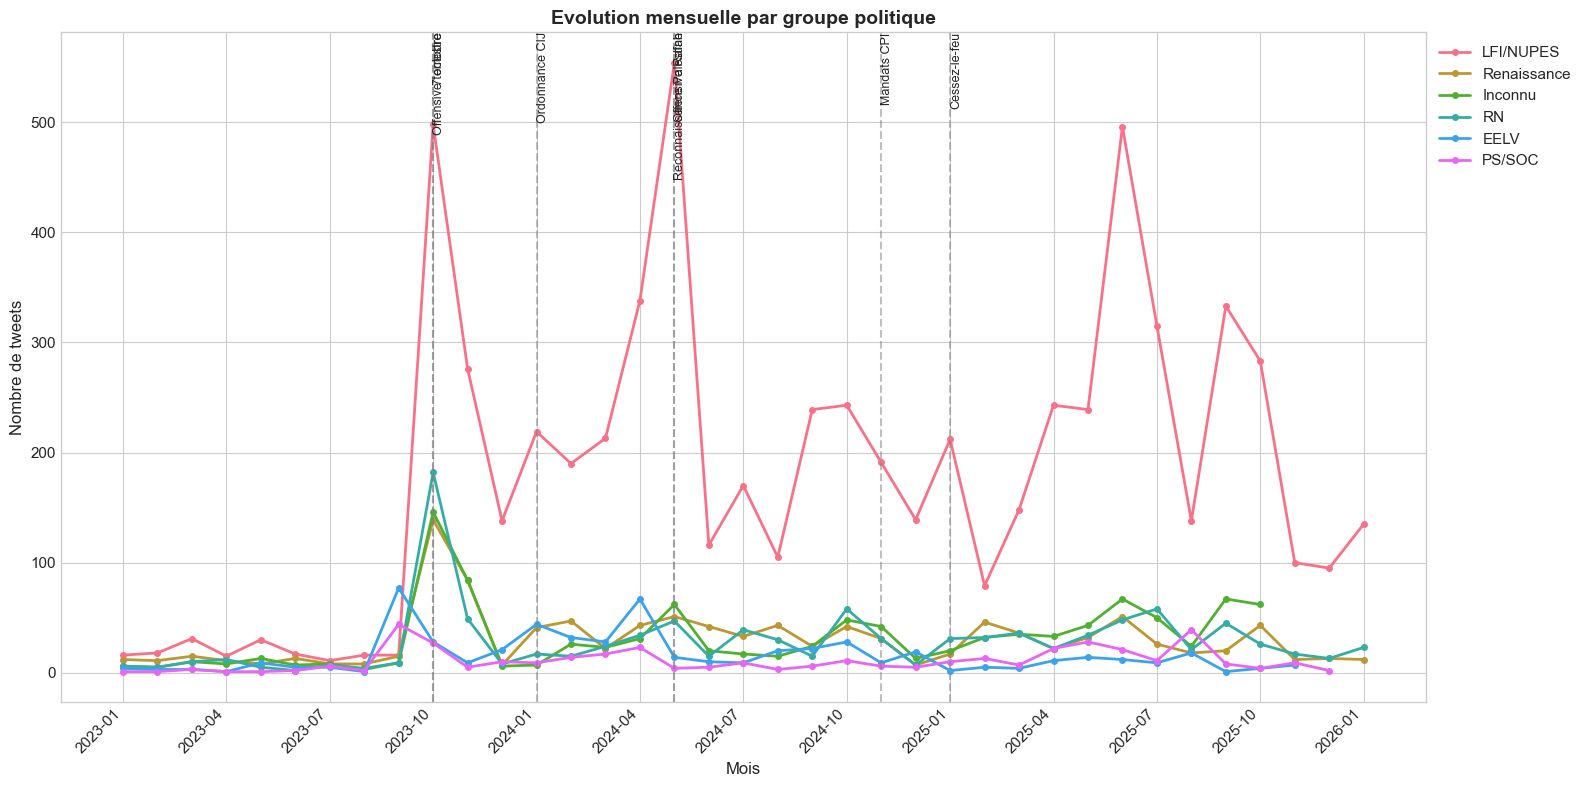

In [20]:
fig, ax = plt.subplots(figsize=(16, 8))

# Top 6 groupes pour lisibilite
top_groups = tweets_df["groupe_norm"].value_counts().head(6).index.tolist()

for group in top_groups:
    group_df = tweets_df[tweets_df["groupe_norm"] == group]
    monthly = group_df.groupby("year_month").size()
    ax.plot(
        range(len(monthly)),
        monthly.values,
        label=group,
        linewidth=2,
        marker="o",
        markersize=4,
    )

# Evenements
for event_name, event_date in EVENTS.items():
    event_period = pd.to_datetime(event_date).to_period("M")
    all_months = tweets_df["year_month"].unique()
    all_months_sorted = sorted(all_months)
    if event_period in all_months_sorted:
        idx = list(all_months_sorted).index(event_period)
        ax.axvline(x=idx, color="gray", linestyle="--", alpha=0.5)
        ax.text(idx, ax.get_ylim()[1], event_name, rotation=90, fontsize=9, va="top")

ax.set_title("Evolution mensuelle par groupe politique", fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de tweets")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Labels x
all_months_sorted = sorted(tweets_df["year_month"].unique())
tick_pos = list(range(0, len(all_months_sorted), 3))
tick_labels = [str(all_months_sorted[i])[:7] for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "evolution_par_groupe.png", dpi=150, bbox_inches="tight")
plt.show()

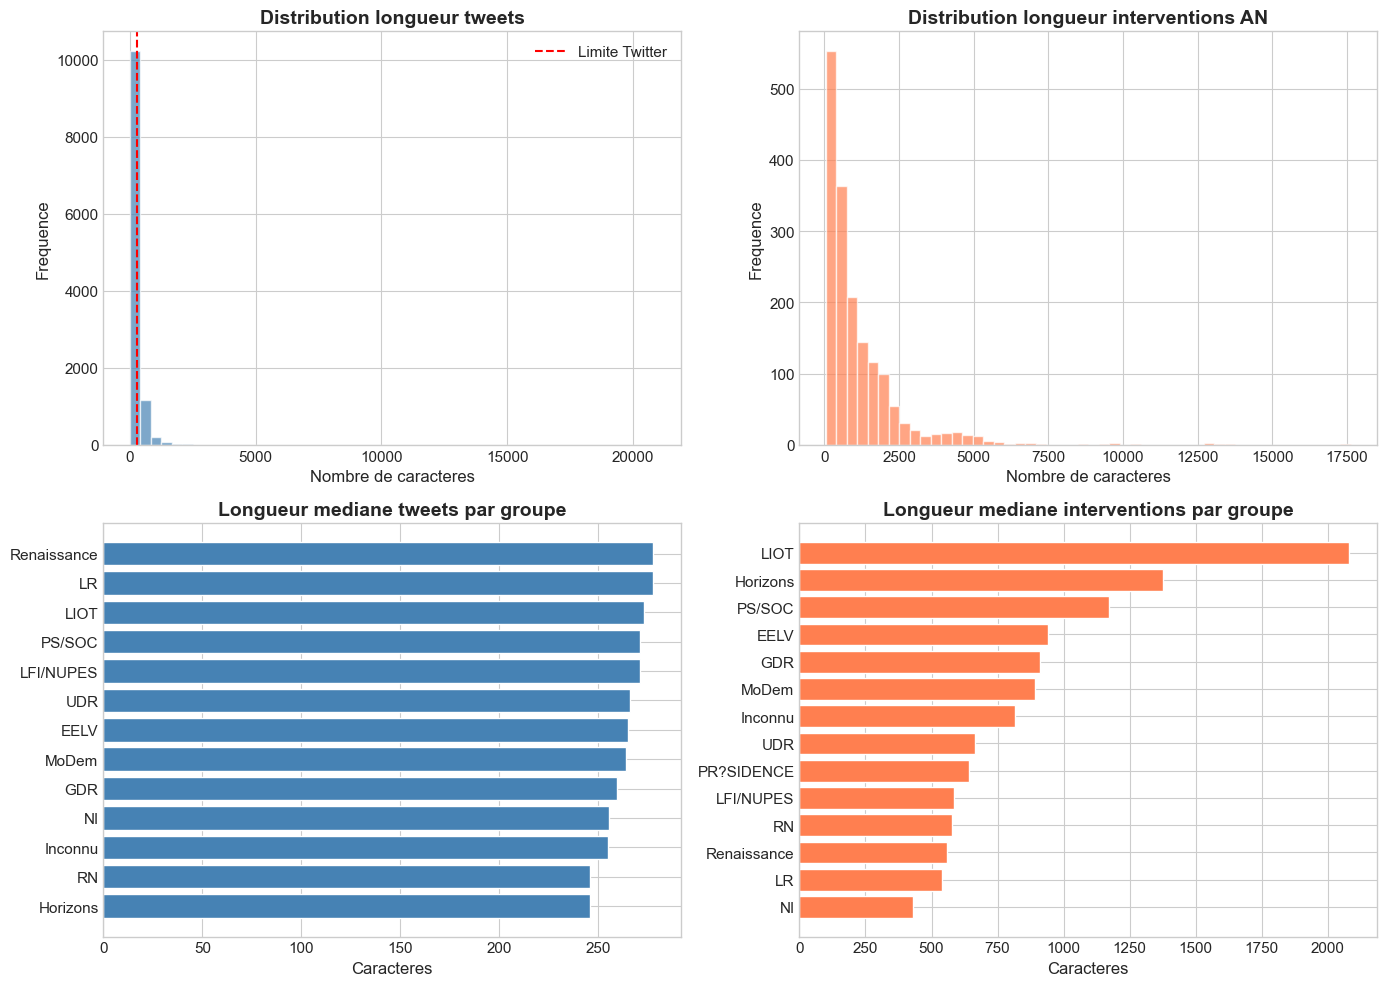


Statistiques longueur:
Tweets: min=5, max=20854, median=269
AN: min=45, max=17626, median=662


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Longueur tweets
tweets_df["text_length"] = tweets_df["text"].str.len()
axes[0, 0].hist(
    tweets_df["text_length"], bins=50, color="steelblue", edgecolor="white", alpha=0.7
)
axes[0, 0].axvline(x=280, color="red", linestyle="--", label="Limite Twitter")
axes[0, 0].set_title("Distribution longueur tweets", fontweight="bold")
axes[0, 0].set_xlabel("Nombre de caracteres")
axes[0, 0].set_ylabel("Frequence")
axes[0, 0].legend()

# Longueur interventions
interv_df["text_length"] = interv_df["normalized_text"].str.len()
axes[0, 1].hist(
    interv_df["text_length"], bins=50, color="coral", edgecolor="white", alpha=0.7
)
axes[0, 1].set_title("Distribution longueur interventions AN", fontweight="bold")
axes[0, 1].set_xlabel("Nombre de caracteres")
axes[0, 1].set_ylabel("Frequence")

# Longueur par groupe (tweets)
length_by_group = tweets_df.groupby("groupe_norm")["text_length"].median().sort_values()
axes[1, 0].barh(length_by_group.index, length_by_group.values, color="steelblue")
axes[1, 0].set_title("Longueur mediane tweets par groupe", fontweight="bold")
axes[1, 0].set_xlabel("Caracteres")

# Longueur par groupe (AN)
length_by_group_an = (
    interv_df.groupby("groupe_norm")["text_length"].median().sort_values()
)
axes[1, 1].barh(length_by_group_an.index, length_by_group_an.values, color="coral")
axes[1, 1].set_title("Longueur mediane interventions par groupe", fontweight="bold")
axes[1, 1].set_xlabel("Caracteres")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "analyse_longueur.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nStatistiques longueur:")
print(
    f"Tweets: min={tweets_df['text_length'].min()}, max={tweets_df['text_length'].max()}, median={tweets_df['text_length'].median():.0f}"
)
print(
    f"AN: min={interv_df['text_length'].min()}, max={interv_df['text_length'].max()}, median={interv_df['text_length'].median():.0f}"
)

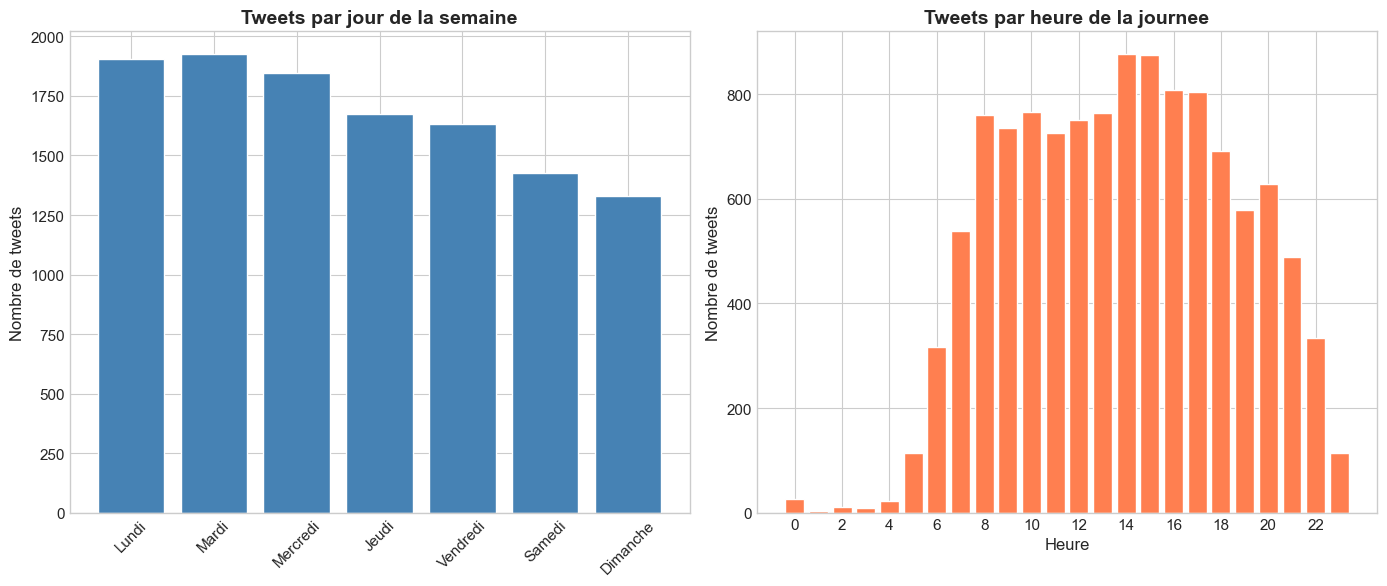

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Par jour de la semaine
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
days_fr = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
day_counts = tweets_df["day_of_week"].value_counts().reindex(days_order)
axes[0].bar(days_fr, day_counts.values, color="steelblue")
axes[0].set_title("Tweets par jour de la semaine", fontweight="bold")
axes[0].set_ylabel("Nombre de tweets")
axes[0].tick_params(axis="x", rotation=45)

# Par heure
hour_counts = tweets_df["hour"].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color="coral")
axes[1].set_title("Tweets par heure de la journee", fontweight="bold")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Nombre de tweets")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "patterns_temporels.png", dpi=150, bbox_inches="tight")
plt.show()

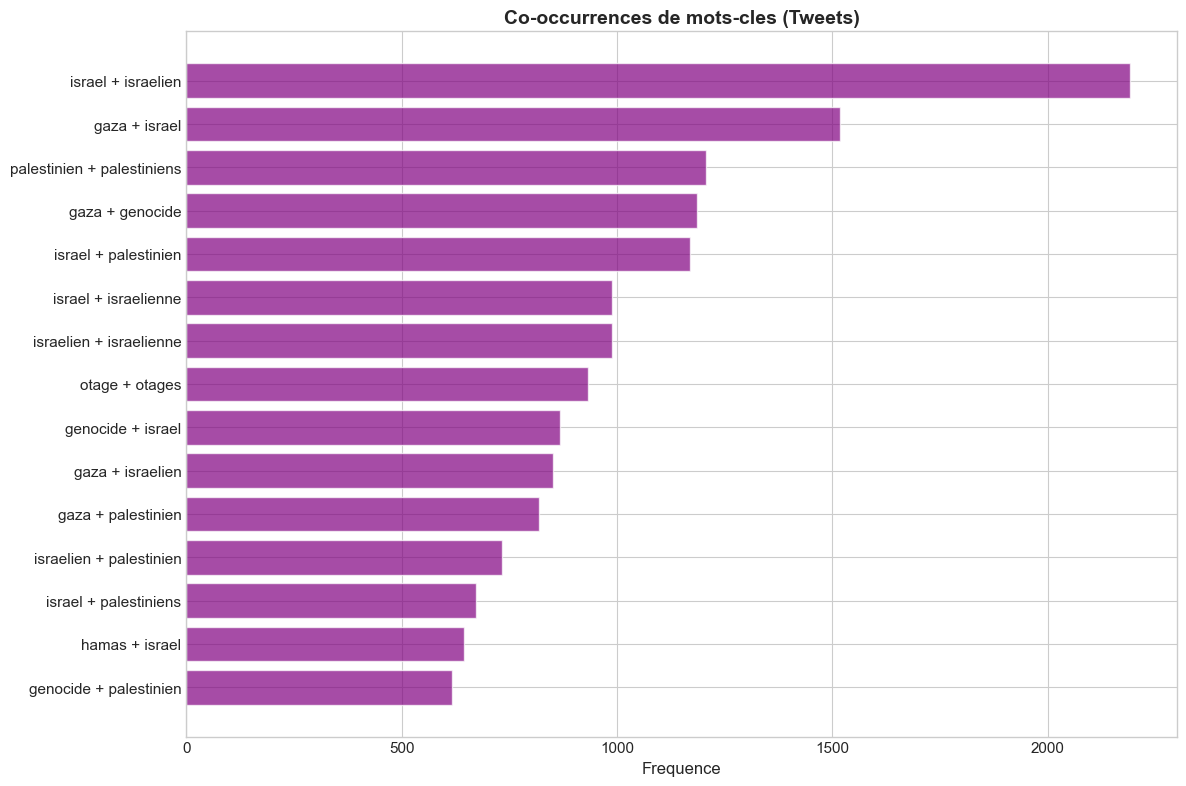

In [23]:
from itertools import combinations


def get_cooccurrences(df, col="keyword_matches", top_n=20):
    cooc = Counter()
    for matches in df[col].dropna():
        if isinstance(matches, np.ndarray):
            kw_list = matches.tolist()
        elif isinstance(matches, list):
            kw_list = matches
        else:
            continue
        if len(kw_list) >= 2:
            for pair in combinations(sorted(set(kw_list)), 2):
                cooc[pair] += 1
    return cooc.most_common(top_n)


cooc_tweets = get_cooccurrences(tweets_df, "keyword_matches", 15)

fig, ax = plt.subplots(figsize=(12, 8))
if cooc_tweets:
    pairs, counts = zip(*cooc_tweets)
    labels = [f"{p[0]} + {p[1]}" for p in pairs]
    ax.barh(labels[::-1], counts[::-1], color="purple", alpha=0.7)
    ax.set_title("Co-occurrences de mots-cles (Tweets)", fontweight="bold")
    ax.set_xlabel("Frequence")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cooccurrences.png", dpi=150, bbox_inches="tight")
plt.show()

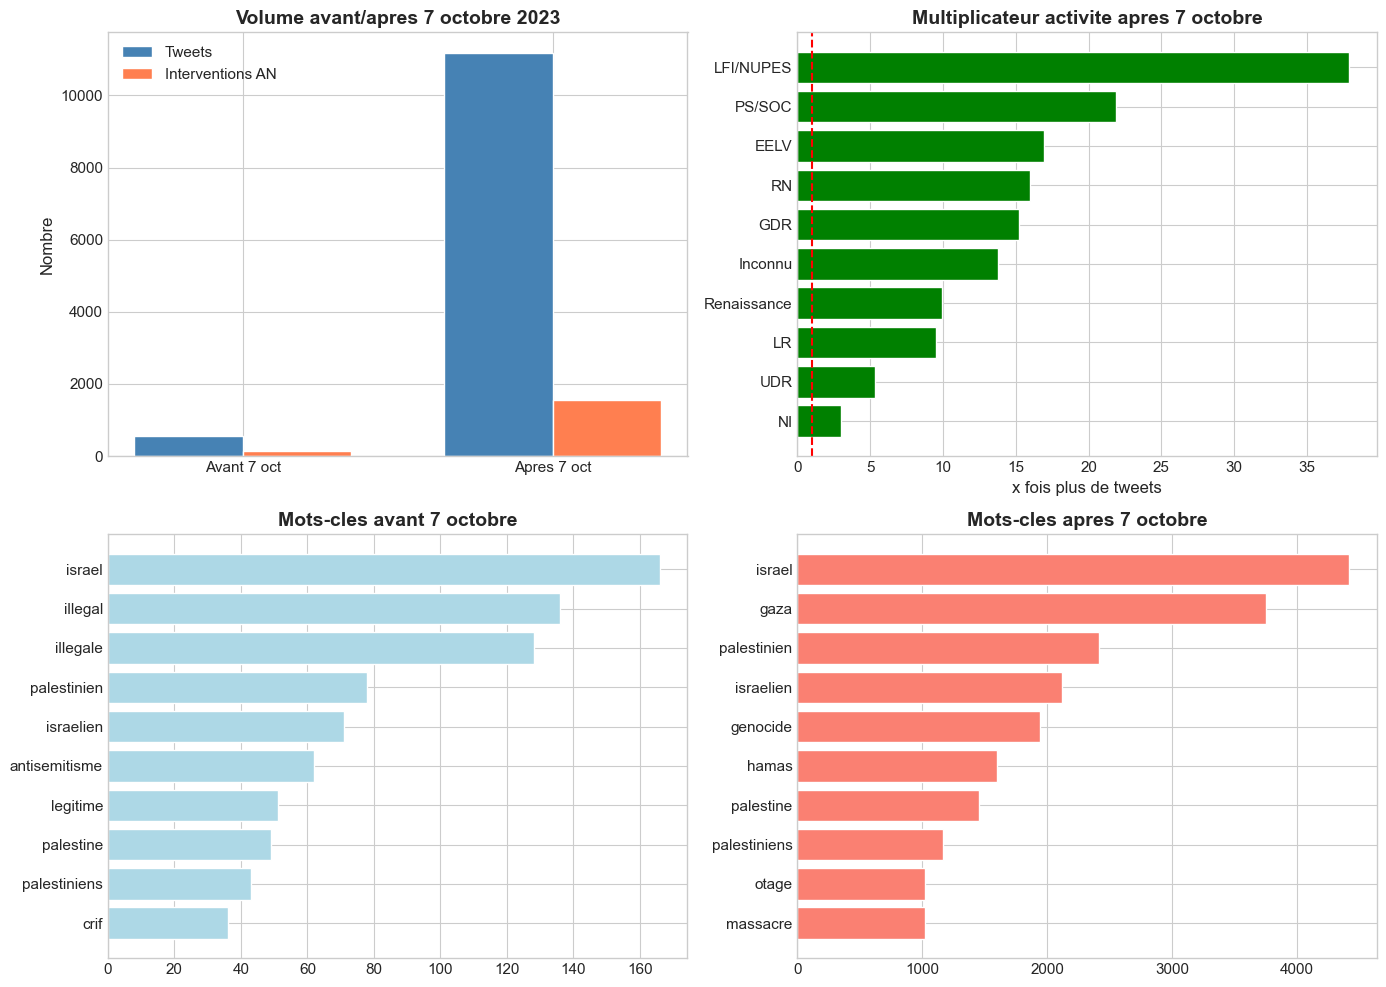


=== STATISTIQUES AVANT/APRES 7 OCTOBRE ===
Tweets avant: 544 (4.6%)
Tweets apres: 11,191 (95.4%)
Interventions avant: 142
Interventions apres: 1,563


In [24]:
date_7oct = pd.to_datetime("2023-10-07")

tweets_before = tweets_df[tweets_df["date"] < date_7oct]
tweets_after = tweets_df[tweets_df["date"] >= date_7oct]

interv_before = interv_df[interv_df["date"] < date_7oct]
interv_after = interv_df[interv_df["date"] >= date_7oct]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Volume avant/apres
volumes = {
    "Tweets": [len(tweets_before), len(tweets_after)],
    "AN": [len(interv_before), len(interv_after)],
}
x = np.arange(2)
width = 0.35
axes[0, 0].bar(
    x - width / 2, volumes["Tweets"], width, label="Tweets", color="steelblue"
)
axes[0, 0].bar(
    x + width / 2, volumes["AN"], width, label="Interventions AN", color="coral"
)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(["Avant 7 oct", "Apres 7 oct"])
axes[0, 0].set_title("Volume avant/apres 7 octobre 2023", fontweight="bold")
axes[0, 0].legend()
axes[0, 0].set_ylabel("Nombre")

# Multiplicateur par groupe
before_by_group = tweets_before["groupe_norm"].value_counts()
after_by_group = tweets_after["groupe_norm"].value_counts()
multipliers = {}
for g in before_by_group.index:
    if before_by_group.get(g, 0) > 10:
        multipliers[g] = after_by_group.get(g, 0) / before_by_group.get(g, 1)

mult_df = pd.Series(multipliers).sort_values(ascending=True)
axes[0, 1].barh(mult_df.index, mult_df.values, color="green")
axes[0, 1].axvline(x=1, color="red", linestyle="--")
axes[0, 1].set_title("Multiplicateur activite apres 7 octobre", fontweight="bold")
axes[0, 1].set_xlabel("x fois plus de tweets")

# Keywords avant
kw_before = extract_keywords(tweets_before)
top_before = kw_before.most_common(10)
if top_before:
    kw, counts = zip(*top_before)
    axes[1, 0].barh(kw[::-1], counts[::-1], color="lightblue")
    axes[1, 0].set_title("Mots-cles avant 7 octobre", fontweight="bold")

# Keywords apres
kw_after = extract_keywords(tweets_after)
top_after = kw_after.most_common(10)
if top_after:
    kw, counts = zip(*top_after)
    axes[1, 1].barh(kw[::-1], counts[::-1], color="salmon")
    axes[1, 1].set_title("Mots-cles apres 7 octobre", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "analyse_7octobre.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== STATISTIQUES AVANT/APRES 7 OCTOBRE ===")
print(
    f"Tweets avant: {len(tweets_before):,} ({len(tweets_before)/len(tweets_df)*100:.1f}%)"
)
print(
    f"Tweets apres: {len(tweets_after):,} ({len(tweets_after)/len(tweets_df)*100:.1f}%)"
)
print(f"Interventions avant: {len(interv_before):,}")
print(f"Interventions apres: {len(interv_after):,}")

In [29]:
# Verifier les colonnes disponibles
print(
    "Colonnes tweets:",
    [c for c in tweets_df.columns if "name" in c.lower() or "depute" in c.lower()],
)
print(
    "Colonnes AN:",
    [c for c in interv_df.columns if "name" in c.lower() or "speaker" in c.lower()],
)


# Utiliser username pour tweets et speaker_name pour AN
# Creer une correspondance par nom normalise
def normalize_name(name):
    if pd.isna(name):
        return ""
    name = str(name).lower().strip()
    # Enlever les accents basiques
    replacements = {
        "é": "e",
        "è": "e",
        "ê": "e",
        "ë": "e",
        "à": "a",
        "â": "a",
        "î": "i",
        "ï": "i",
        "ô": "o",
        "ù": "u",
        "û": "u",
        "ç": "c",
    }
    for old, new in replacements.items():
        name = name.replace(old, new)
    return name


# Pour les tweets, utiliser depute_name si disponible, sinon username
if "depute_name" in tweets_df.columns:
    tweets_df["name_norm"] = tweets_df["depute_name"].apply(normalize_name)
else:
    tweets_df["name_norm"] = tweets_df["username"].apply(normalize_name)

interv_df["name_norm"] = interv_df["speaker_name"].apply(normalize_name)

# Compter par nom normalise
tweets_by_name = tweets_df.groupby("name_norm").size()
interv_by_name = interv_df.groupby("name_norm").size()

# Enlever les vides
tweets_by_name = tweets_by_name[tweets_by_name.index != ""]
interv_by_name = interv_by_name[interv_by_name.index != ""]

print(f"\nNoms uniques tweets: {len(tweets_by_name)}")
print(f"Noms uniques AN: {len(interv_by_name)}")

# Trouver les correspondances approximatives
common_names = set(tweets_by_name.index) & set(interv_by_name.index)
print(f"Correspondances exactes: {len(common_names)}")

# Afficher quelques exemples de noms
print("\nExemples noms tweets:", list(tweets_by_name.index[:5]))
print("Exemples noms AN:", list(interv_by_name.index[:5]))

# Si pas de correspondance exacte, faire un matching par partie du nom
if len(common_names) < 10:
    print("\nRecherche de correspondances partielles...")
    partial_matches = []
    for tw_name in tweets_by_name.index:
        for an_name in interv_by_name.index:
            # Verifier si un nom contient l'autre
            if len(tw_name) > 3 and len(an_name) > 3:
                tw_parts = set(tw_name.split())
                an_parts = set(an_name.split())
                if tw_parts & an_parts:  # Au moins un mot en commun
                    partial_matches.append((tw_name, an_name))

    print(f"Correspondances partielles trouvees: {len(partial_matches)}")
    if partial_matches:
        print("Exemples:", partial_matches[:5])

Colonnes tweets: ['username', 'depute_name']
Colonnes AN: ['speaker_name', 'speaker_quality', 'speaker_uid', 'speaker_mandate_id', 'matched_name']

Noms uniques tweets: 204
Noms uniques AN: 349
Correspondances exactes: 0

Exemples noms tweets: ['adrien quatennens', 'agnes firmin le bodo', 'alexandre portier', 'alexandre sabatou', 'alexis jolly']
Exemples noms AN: ['m. adrien quatennens', 'm. alain david', 'm. alexandre portier', 'm. alexandre sabatou', 'm. alexis jolly']

Recherche de correspondances partielles...
Correspondances partielles trouvees: 566
Exemples: [('adrien quatennens', 'm. adrien quatennens'), ('agnes firmin le bodo', 'm. arnaud le gall'), ('agnes firmin le bodo', 'm. le president'), ('agnes firmin le bodo', 'm. tematai le gayic'), ('agnes firmin le bodo', 'mme constance le grip')]


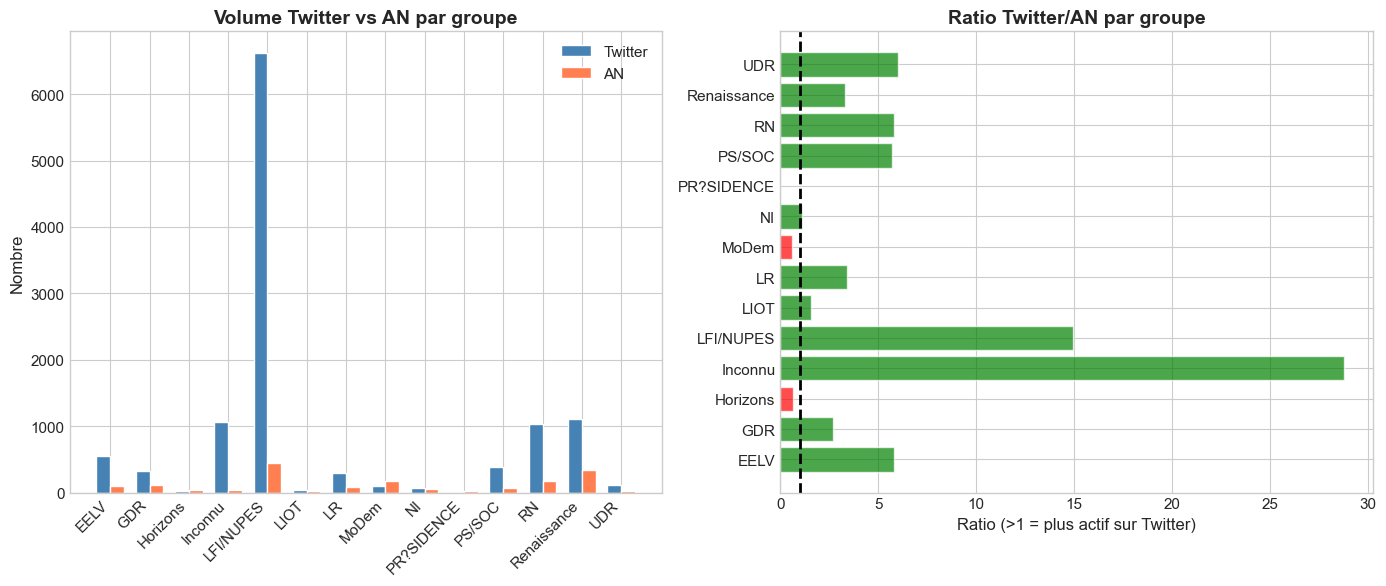


Ratio Twitter/AN par groupe:
  Inconnu: 28.8x
  LFI/NUPES: 15.0x
  UDR: 6.0x
  RN: 5.8x
  EELV: 5.8x
  PS/SOC: 5.7x
  LR: 3.4x
  Renaissance: 3.3x
  GDR: 2.7x
  LIOT: 1.6x
  NI: 1.1x
  Horizons: 0.7x
  MoDem: 0.6x
  PR?SIDENCE: 0.0x


In [30]:
# Version alternative: comparer par groupe politique plutot que par depute
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Volume par groupe - Twitter vs AN
groups_tw = tweets_df["groupe_norm"].value_counts()
groups_an = interv_df["groupe_norm"].value_counts()

all_groups = sorted(set(groups_tw.index) | set(groups_an.index))
x = np.arange(len(all_groups))
width = 0.35

tw_vals = [groups_tw.get(g, 0) for g in all_groups]
an_vals = [groups_an.get(g, 0) for g in all_groups]

axes[0].bar(x - width / 2, tw_vals, width, label="Twitter", color="steelblue")
axes[0].bar(x + width / 2, an_vals, width, label="AN", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_groups, rotation=45, ha="right")
axes[0].set_title("Volume Twitter vs AN par groupe", fontweight="bold")
axes[0].set_ylabel("Nombre")
axes[0].legend()

# Ratio Twitter/AN par groupe
ratios = []
for g in all_groups:
    tw = groups_tw.get(g, 0)
    an = groups_an.get(g, 1)
    ratios.append(tw / an if an > 0 else 0)

colors = ["green" if r > 1 else "red" for r in ratios]
axes[1].barh(all_groups, ratios, color=colors, alpha=0.7)
axes[1].axvline(x=1, color="black", linestyle="--", linewidth=2)
axes[1].set_title("Ratio Twitter/AN par groupe", fontweight="bold")
axes[1].set_xlabel("Ratio (>1 = plus actif sur Twitter)")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "comparaison_arenes_groupes.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("\nRatio Twitter/AN par groupe:")
for g, r in sorted(zip(all_groups, ratios), key=lambda x: x[1], reverse=True):
    print(f"  {g}: {r:.1f}x")

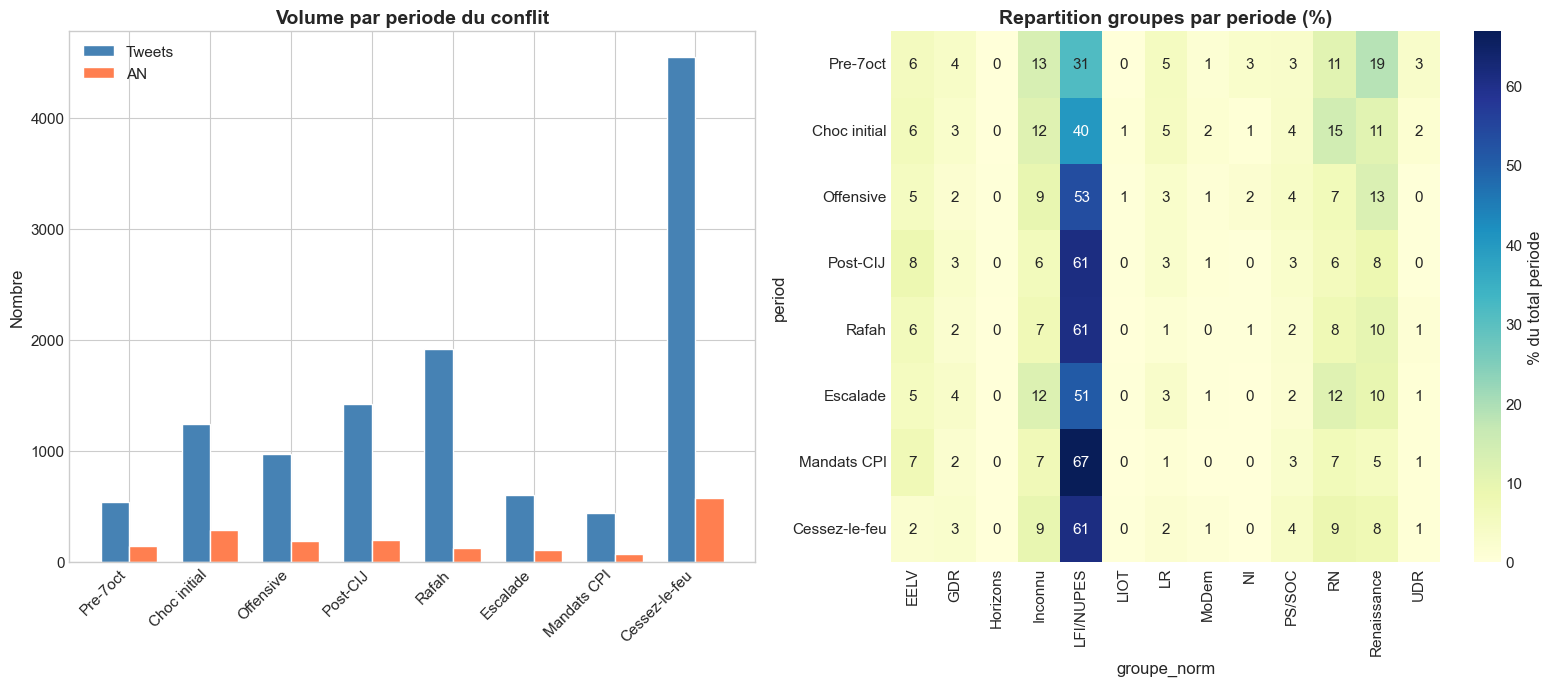

In [26]:
# Definir les periodes
PERIODS = {
    "P0: Pre-7oct": ("2023-01-01", "2023-10-06"),
    "P1: Choc initial": ("2023-10-07", "2023-10-31"),
    "P2: Offensive": ("2023-11-01", "2024-01-25"),
    "P3: Post-CIJ": ("2024-01-26", "2024-05-05"),
    "P4: Rafah": ("2024-05-06", "2024-09-30"),
    "P5: Escalade": ("2024-10-01", "2024-11-20"),
    "P6: Mandats CPI": ("2024-11-21", "2025-01-14"),
    "P7: Cessez-le-feu": ("2025-01-15", "2026-12-31"),
}


def assign_period(date):
    for period_name, (start, end) in PERIODS.items():
        if pd.to_datetime(start) <= date <= pd.to_datetime(end):
            return period_name
    return "Autre"


tweets_df["period"] = tweets_df["date"].apply(assign_period)
interv_df["period"] = interv_df["date"].apply(assign_period)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Volume par periode
period_order = list(PERIODS.keys())
tweets_by_period = tweets_df["period"].value_counts().reindex(period_order).fillna(0)
interv_by_period = interv_df["period"].value_counts().reindex(period_order).fillna(0)

x = np.arange(len(period_order))
width = 0.35
axes[0].bar(
    x - width / 2, tweets_by_period.values, width, label="Tweets", color="steelblue"
)
axes[0].bar(x + width / 2, interv_by_period.values, width, label="AN", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [p.split(": ")[1] for p in period_order], rotation=45, ha="right"
)
axes[0].set_title("Volume par periode du conflit", fontweight="bold")
axes[0].legend()
axes[0].set_ylabel("Nombre")

# Distribution groupes par periode (heatmap)
period_group = tweets_df.groupby(["period", "groupe_norm"]).size().unstack(fill_value=0)
period_group = period_group.reindex(period_order)
# Normaliser par ligne
period_group_norm = period_group.div(period_group.sum(axis=1), axis=0) * 100

sns.heatmap(
    period_group_norm,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    ax=axes[1],
    cbar_kws={"label": "% du total periode"},
)
axes[1].set_title("Repartition groupes par periode (%)", fontweight="bold")
axes[1].set_yticklabels([p.split(": ")[1] for p in period_order], rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "analyse_periodes.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
print("=" * 70)
print("STATISTIQUES DESCRIPTIVES FINALES")
print("=" * 70)

# S'assurer que engagement existe
if "engagement" not in tweets_df.columns:
    tweets_df["engagement"] = tweets_df["likes"].fillna(0) + tweets_df[
        "retweets"
    ].fillna(0)

if "text_length" not in tweets_df.columns:
    tweets_df["text_length"] = tweets_df["text"].str.len()

if "text_length" not in interv_df.columns:
    interv_df["text_length"] = interv_df["normalized_text"].str.len()

print("\n--- TWEETS ---")
print(f"Total: {len(tweets_df):,}")
print(f"Utilisateurs uniques: {tweets_df['username'].nunique()}")

is_rt = tweets_df["is_retweet"].fillna(False).astype(bool)
is_reply = tweets_df["is_reply"].fillna(False).astype(bool)
has_media = tweets_df["has_media"].fillna(False).astype(bool)

print(f"Tweets originaux: {(~is_rt).sum():,} ({(~is_rt).mean()*100:.1f}%)")
print(f"Retweets: {is_rt.sum():,} ({is_rt.mean()*100:.1f}%)")
print(f"Replies: {is_reply.sum():,} ({is_reply.mean()*100:.1f}%)")
print(f"Avec media: {has_media.sum():,} ({has_media.mean()*100:.1f}%)")
print(f"Longueur moyenne: {tweets_df['text_length'].mean():.0f} caracteres")
print(f"Engagement median: {tweets_df['engagement'].median():.0f}")

print("\n--- INTERVENTIONS AN ---")
print(f"Total: {len(interv_df):,}")
print(f"Orateurs uniques: {interv_df['speaker_name'].nunique()}")
print(f"Longueur moyenne: {interv_df['text_length'].mean():.0f} caracteres")

print("\n--- PAR GROUPE (Tweets) ---")
group_stats = (
    tweets_df.groupby("groupe_norm")
    .agg({"username": "nunique", "text_length": "mean", "engagement": "median"})
    .round(1)
)
group_stats.columns = ["Deputes", "Long. moy", "Engagement"]
group_stats["Tweets"] = tweets_df["groupe_norm"].value_counts()
group_stats["% RT"] = (
    tweets_df.groupby("groupe_norm")["is_retweet"]
    .apply(lambda x: x.fillna(False).mean() * 100)
    .round(1)
)
group_stats = group_stats[["Tweets", "Deputes", "Long. moy", "Engagement", "% RT"]]
group_stats = group_stats.sort_values("Tweets", ascending=False)
print(group_stats.to_string())

print("\n--- PERIODES ---")
if "period" in tweets_df.columns:
    period_stats = tweets_df.groupby("period").agg(
        {"username": "nunique", "engagement": "median"}
    )
    period_stats["Tweets"] = tweets_df["period"].value_counts()
    period_stats = period_stats.sort_index()
    print(period_stats.to_string())

STATISTIQUES DESCRIPTIVES FINALES

--- TWEETS ---
Total: 11,735
Utilisateurs uniques: 264
Tweets originaux: 11,735 (100.0%)
Retweets: 0 (0.0%)
Replies: 0 (0.0%)
Avec media: 0 (0.0%)
Longueur moyenne: 306 caracteres
Engagement median: 109

--- INTERVENTIONS AN ---
Total: 1,705
Orateurs uniques: 349
Longueur moyenne: 1136 caracteres

--- PAR GROUPE (Tweets) ---
             Tweets  Deputes  Long. moy  Engagement  % RT
groupe_norm                                              
LFI/NUPES      6615       44      310.2       202.0   0.0
Renaissance    1105       40      396.7        56.0   0.0
Inconnu        1066       60      250.0        31.0   0.0
RN             1037       37      279.7        67.0   0.0
EELV            555       13      267.3        37.0   0.0
PS/SOC          389       13      282.1       196.0   0.0
GDR             324        7      261.0        86.5   0.0
LR              295       17      328.7        33.0   0.0
UDR             114        4      300.1       243.5   0.0


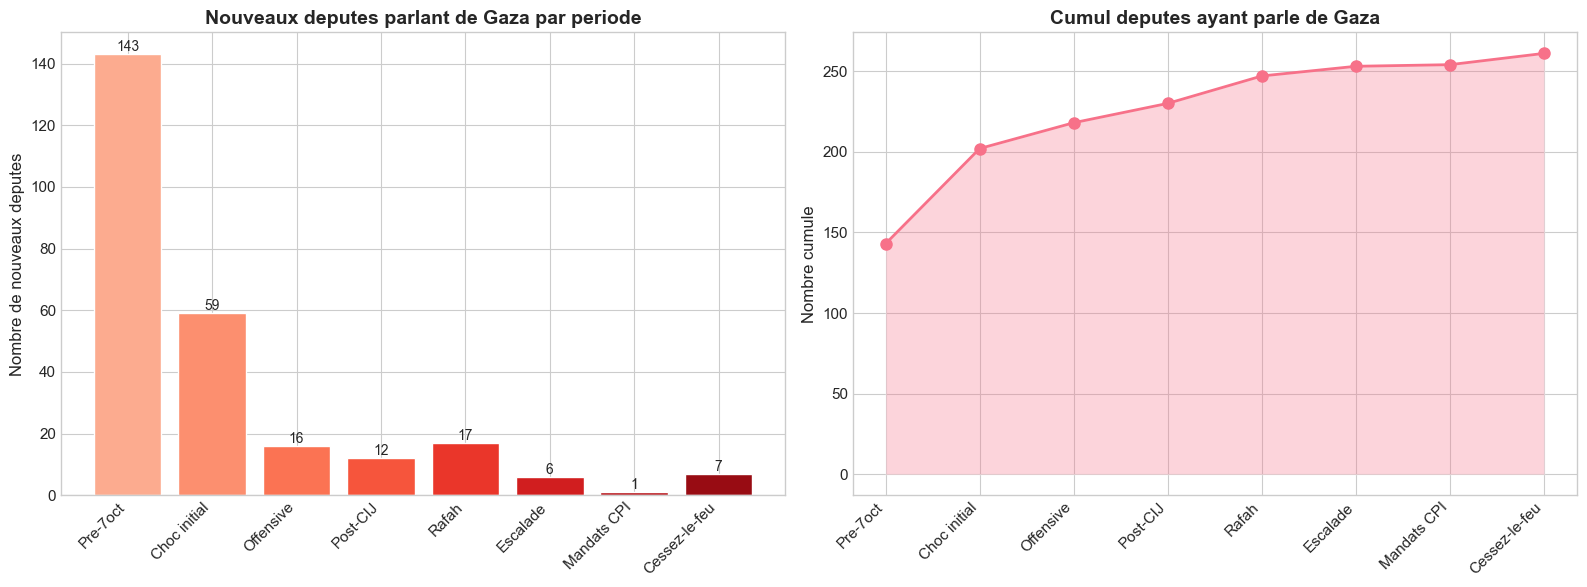


=== NOUVEAUX ENTRANTS PAR PERIODE ===

P0: Pre-7oct (143 nouveaux):
  - @_evasas (EELV)
  - @a_saintoul (LFI/NUPES)
  - @abomangoli (LFI/NUPES)
  - @agnesfirmin (Horizons)
  - @alexiscorbiere (Inconnu)
  - @alexisjollyrn (RN)
  - @alma_dufour (LFI/NUPES)
  - @alydiouara (Inconnu)
  - @aquatennens (LFI/NUPES)
  - @arenasrodrigo_ (Inconnu)
  ... et 133 autres

P1: Choc initial (59 nouveaux):
  - @abadiecaroline (Renaissance)
  - @aleaument (LFI/NUPES)
  - @amiel_david_ (Inconnu)
  - @annececilevio (Horizons)
  - @annelaureblin (Inconnu)
  - @antboulogne54 (Inconnu)
  - @b_belhaddad (Renaissance)
  - @beaurainjose (Inconnu)
  - @belouassaanais (Inconnu)
  - @benbrahim_k (Inconnu)
  ... et 49 autres

P2: Offensive (16 nouveaux):
  - @amelia_lkf (Renaissance)
  - @deputecausse (Inconnu)
  - @frantzgumbs (MoDem)
  - @frdric_maillot (GDR)
  - @jp_mattei (MoDem)
  - @karinelebon (GDR)
  - @labaronnedaniel (Renaissance)
  - @lisabelluco (EELV)
  - @loickervran18 (Horizons)
  - @mathieulefevre_

In [32]:
# Identifier quand chaque depute a commence a parler du sujet
first_tweet = tweets_df.groupby("username")["date"].min().reset_index()
first_tweet.columns = ["username", "first_tweet_date"]
first_tweet["first_period"] = first_tweet["first_tweet_date"].apply(assign_period)

# Compter les nouveaux entrants par periode
new_entrants = first_tweet["first_period"].value_counts()
period_order = [
    "P0: Pre-7oct",
    "P1: Choc initial",
    "P2: Offensive",
    "P3: Post-CIJ",
    "P4: Rafah",
    "P5: Escalade",
    "P6: Mandats CPI",
    "P7: Cessez-le-feu",
]
new_entrants = new_entrants.reindex(period_order).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique nouveaux entrants
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(new_entrants)))
bars = axes[0].bar(range(len(new_entrants)), new_entrants.values, color=colors)
axes[0].set_xticks(range(len(new_entrants)))
axes[0].set_xticklabels(
    [p.split(": ")[1] for p in period_order], rotation=45, ha="right"
)
axes[0].set_title("Nouveaux deputes parlant de Gaza par periode", fontweight="bold")
axes[0].set_ylabel("Nombre de nouveaux deputes")

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, new_entrants.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(val)),
        ha="center",
        fontsize=10,
    )

# Cumule
cumul = new_entrants.cumsum()
axes[1].plot(range(len(cumul)), cumul.values, marker="o", linewidth=2, markersize=8)
axes[1].fill_between(range(len(cumul)), cumul.values, alpha=0.3)
axes[1].set_xticks(range(len(cumul)))
axes[1].set_xticklabels(
    [p.split(": ")[1] for p in period_order], rotation=45, ha="right"
)
axes[1].set_title("Cumul deputes ayant parle de Gaza", fontweight="bold")
axes[1].set_ylabel("Nombre cumule")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "nouveaux_entrants.png", dpi=150, bbox_inches="tight")
plt.show()

# Liste des nouveaux entrants par periode
print("\n=== NOUVEAUX ENTRANTS PAR PERIODE ===")
for period in period_order:
    entrants = first_tweet[first_tweet["first_period"] == period]
    if len(entrants) > 0:
        print(f"\n{period} ({len(entrants)} nouveaux):")
        # Ajouter le groupe politique
        entrants_with_group = entrants.merge(
            tweets_df[["username", "groupe_norm"]].drop_duplicates(), on="username"
        )
        for _, row in entrants_with_group.head(10).iterrows():
            print(f"  - @{row['username']} ({row['groupe_norm']})")
        if len(entrants) > 10:
            print(f"  ... et {len(entrants) - 10} autres")

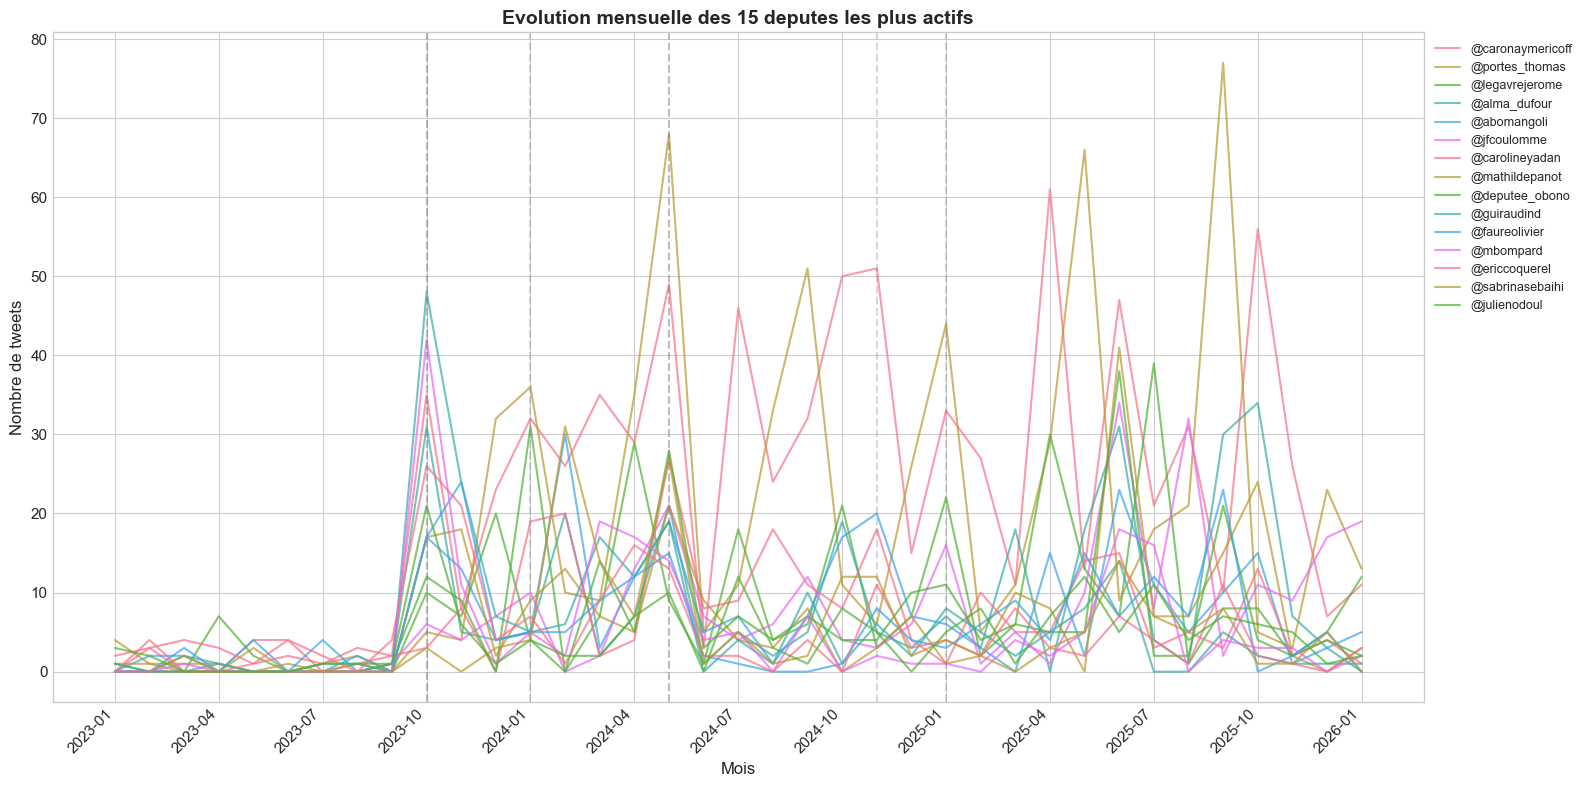

In [33]:
# Pour les deputes les plus actifs, voir leur evolution
top_users = tweets_df["username"].value_counts().head(15).index.tolist()

fig, ax = plt.subplots(figsize=(16, 8))

for user in top_users:
    user_df = tweets_df[tweets_df["username"] == user]
    monthly = user_df.groupby("year_month").size()

    # Creer un index complet
    all_months = sorted(tweets_df["year_month"].unique())
    monthly = monthly.reindex(all_months, fill_value=0)

    ax.plot(
        range(len(monthly)), monthly.values, label=f"@{user}", alpha=0.7, linewidth=1.5
    )

# Marquer les evenements
for event_name, event_date in EVENTS.items():
    event_period = pd.to_datetime(event_date).to_period("M")
    if event_period in all_months:
        idx = list(all_months).index(event_period)
        ax.axvline(x=idx, color="gray", linestyle="--", alpha=0.3)

ax.set_title("Evolution mensuelle des 15 deputes les plus actifs", fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de tweets")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9)

tick_pos = list(range(0, len(all_months), 3))
tick_labels = [str(all_months[i])[:7] for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "evolution_top_users.png", dpi=150, bbox_inches="tight")
plt.show()

=== DEPUTES AVEC PICS D'ACTIVITE SIGNIFICATIFS ===
(Activite > 2x ecart-type au-dessus de la moyenne)

       username      groupe max_month  max_tweets  mean_tweets  spike_ratio
 jerome_buisson          RN   2023-10          43     5.400000     7.962963
      pycadalen   LFI/NUPES   2025-06          37     5.157895     7.173469
fcbdeputeducher Renaissance   2023-10          29     4.173913     6.947917
    ericpauget1          LR   2023-10          14     2.038462     6.867925
guillaume_bigot          RN   2023-10          17     2.562500     6.634146
     guiraudind   LFI/NUPES   2023-10          48     7.333333     6.545455
        eciotti         UDR   2023-10          20     3.400000     5.882353
      h2lepinau          RN   2023-10          14     2.388889     5.860465
       mtabarot          LR   2023-10          24     4.185185     5.734513
 benjaminhaddad Renaissance   2023-10          13     2.307692     5.633333
   amiel_david_     Inconnu   2023-10          15     2.80000

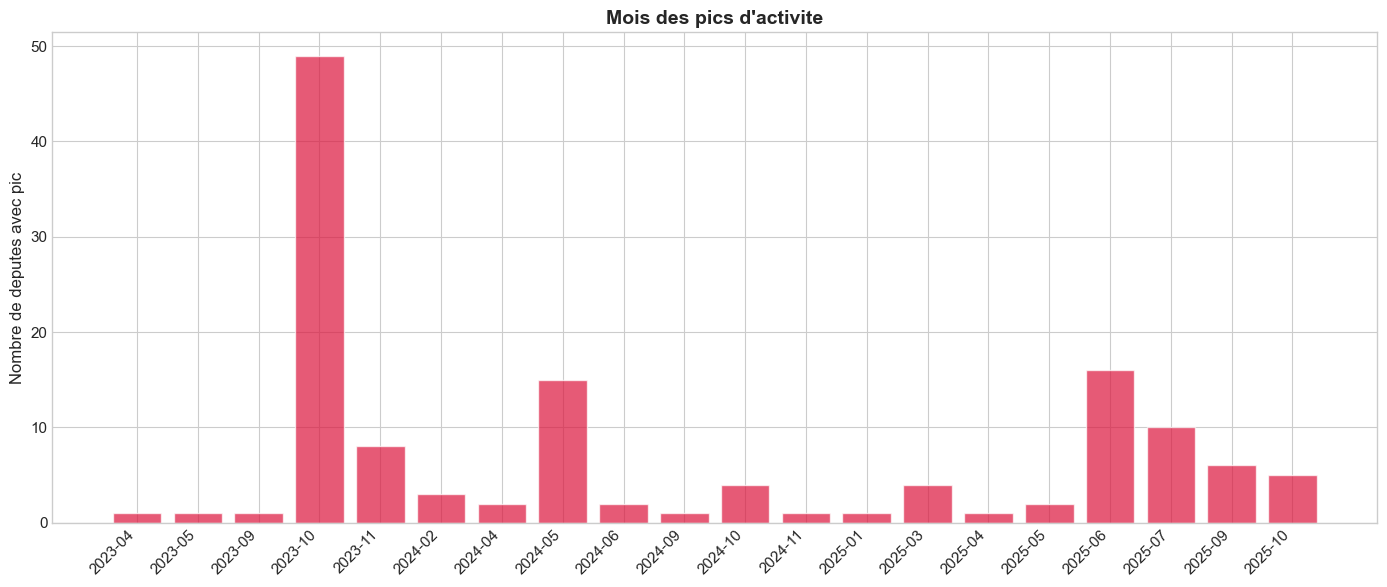

In [34]:
# Detecter les deputes qui ont eu un "pic" soudain d'activite
def detect_activity_spike(user_data, threshold=3):
    """Detecte si un depute a eu un pic d'activite."""
    if len(user_data) < 5:
        return None

    monthly = user_data.groupby("year_month").size()
    if len(monthly) < 3:
        return None

    # Calculer la moyenne mobile et l'ecart-type
    mean_activity = monthly.mean()
    std_activity = monthly.std()

    if std_activity == 0:
        return None

    # Trouver les mois avec activite > mean + threshold * std
    spikes = monthly[monthly > mean_activity + threshold * std_activity]

    if len(spikes) > 0:
        return {
            "max_month": str(spikes.idxmax()),
            "max_value": spikes.max(),
            "mean": mean_activity,
            "spike_ratio": spikes.max() / mean_activity,
        }
    return None


# Analyser tous les deputes
spike_analysis = []
for user in tweets_df["username"].unique():
    user_data = tweets_df[tweets_df["username"] == user]
    spike = detect_activity_spike(user_data, threshold=2)
    if spike:
        groupe = user_data["groupe_norm"].iloc[0]
        spike_analysis.append(
            {
                "username": user,
                "groupe": groupe,
                "max_month": spike["max_month"],
                "max_tweets": spike["max_value"],
                "mean_tweets": spike["mean"],
                "spike_ratio": spike["spike_ratio"],
            }
        )

spike_df = pd.DataFrame(spike_analysis)
spike_df = spike_df.sort_values("spike_ratio", ascending=False)

print("=== DEPUTES AVEC PICS D'ACTIVITE SIGNIFICATIFS ===")
print(f"(Activite > 2x ecart-type au-dessus de la moyenne)\n")

print(spike_df.head(20).to_string(index=False))

# Visualiser les pics par periode
if len(spike_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))

    spike_by_month = spike_df["max_month"].value_counts().sort_index()
    ax.bar(
        range(len(spike_by_month)), spike_by_month.values, color="crimson", alpha=0.7
    )
    ax.set_xticks(range(len(spike_by_month)))
    ax.set_xticklabels(spike_by_month.index, rotation=45, ha="right")
    ax.set_title("Mois des pics d'activite", fontweight="bold")
    ax.set_ylabel("Nombre de deputes avec pic")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pics_activite.png", dpi=150, bbox_inches="tight")
    plt.show()

=== DEPUTES SILENCIEUX DEVENUS ACTIFS APRES LE 7 OCTOBRE ===
(Max 2 tweets avant, au moins 10 apres)

Total: 89 deputes

       username      groupe  tweets_avant_7oct  tweets_apres_7oct premier_tweet
    alma_dufour   LFI/NUPES                  2                291    2023-04-06
     jfcoulomme   LFI/NUPES                  1                270    2023-09-22
  deputee_obono   LFI/NUPES                  2                244    2023-01-29
       mbompard   LFI/NUPES                  1                188    2023-03-23
 sabrinasebaihi        EELV                  2                179    2023-03-01
  hadrienclouet   LFI/NUPES                  1                148    2023-09-29
  nathalieoziol   LFI/NUPES                  2                139    2023-05-04
  gabriellecthl   LFI/NUPES                  0                136    2024-05-28
  christophebex     Inconnu                  1                110    2023-06-23
clemence_guette   LFI/NUPES                  0                102    2023-10-27

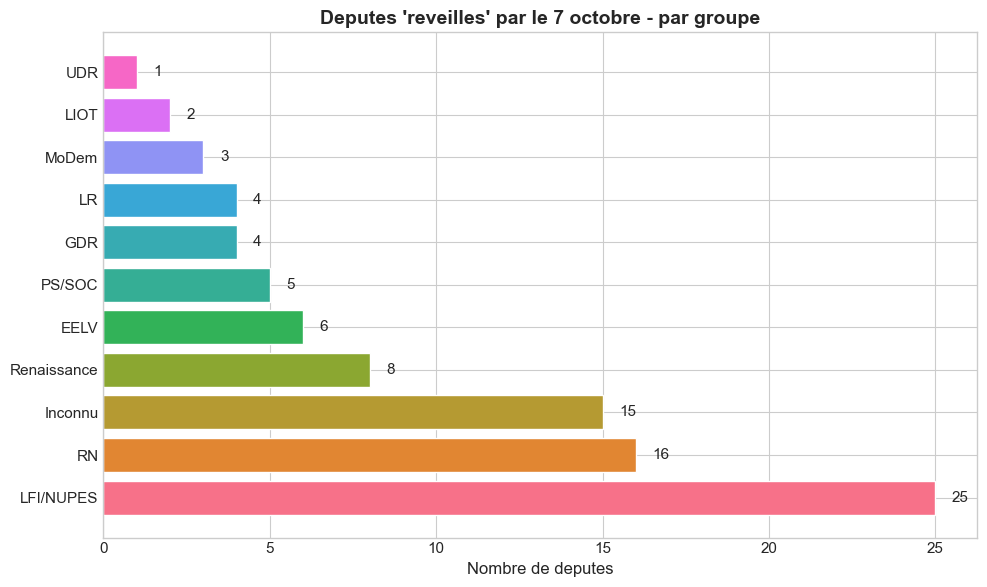

In [35]:
# Identifier les deputes qui etaient silencieux avant le 7 octobre et sont devenus actifs
date_7oct = pd.to_datetime("2023-10-07")

tweets_before = tweets_df[tweets_df["date"] < date_7oct]
tweets_after = tweets_df[tweets_df["date"] >= date_7oct]

# Compter par utilisateur
before_counts = tweets_before.groupby("username").size()
after_counts = tweets_after.groupby("username").size()

# Deputes actifs seulement apres le 7 octobre (ou quasi)
silent_before = []
for user in tweets_df["username"].unique():
    before = before_counts.get(user, 0)
    after = after_counts.get(user, 0)

    if before <= 2 and after >= 10:  # Quasi-silencieux avant, actif apres
        groupe = tweets_df[tweets_df["username"] == user]["groupe_norm"].iloc[0]
        first_date = tweets_df[tweets_df["username"] == user]["date"].min()
        silent_before.append(
            {
                "username": user,
                "groupe": groupe,
                "tweets_avant_7oct": before,
                "tweets_apres_7oct": after,
                "premier_tweet": first_date.strftime("%Y-%m-%d"),
            }
        )

silent_df = pd.DataFrame(silent_before)
silent_df = silent_df.sort_values("tweets_apres_7oct", ascending=False)

print("=== DEPUTES SILENCIEUX DEVENUS ACTIFS APRES LE 7 OCTOBRE ===")
print(f"(Max 2 tweets avant, au moins 10 apres)\n")
print(f"Total: {len(silent_df)} deputes\n")
print(silent_df.head(25).to_string(index=False))

# Par groupe politique
if len(silent_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    by_group = silent_df["groupe"].value_counts()
    colors = sns.color_palette("husl", len(by_group))
    ax.barh(by_group.index, by_group.values, color=colors)
    ax.set_title("Deputes 'reveilles' par le 7 octobre - par groupe", fontweight="bold")
    ax.set_xlabel("Nombre de deputes")

    for i, (idx, val) in enumerate(by_group.items()):
        ax.text(val + 0.5, i, str(val), va="center")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "deputes_reveilles.png", dpi=150, bbox_inches="tight")
    plt.show()

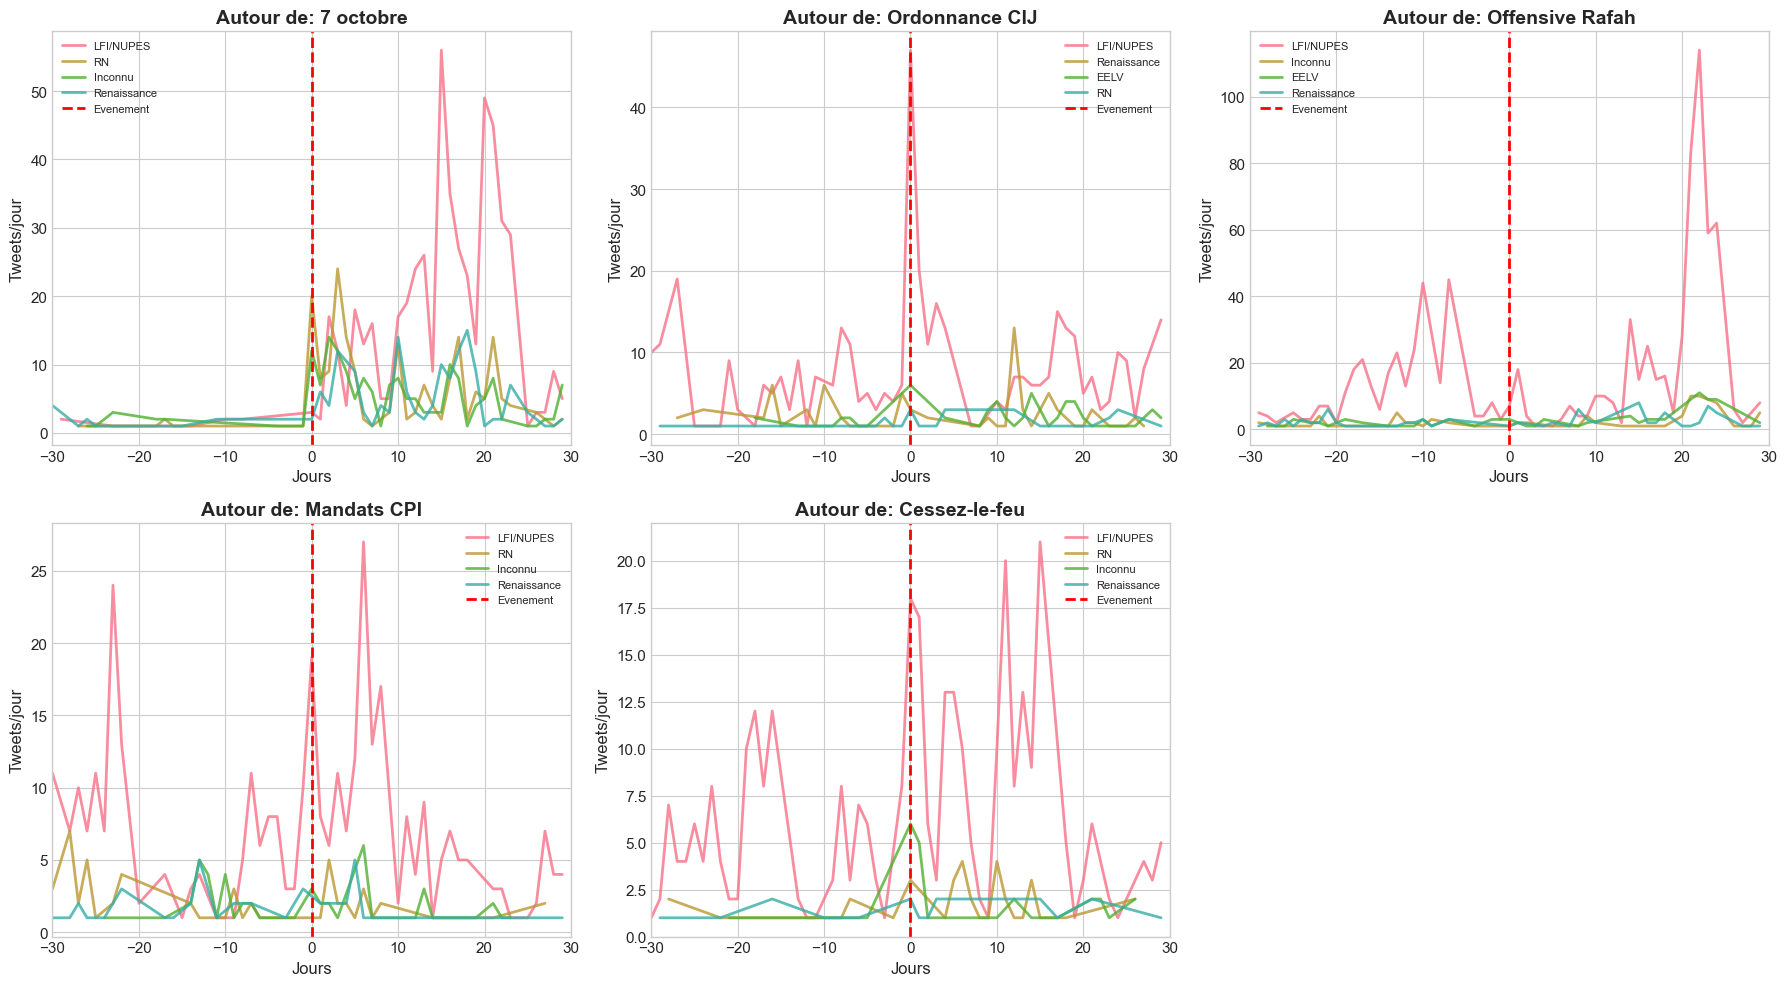

In [36]:
# Analyser l'evolution de chaque groupe autour des evenements cles
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

events_to_analyze = [
    ("7 octobre", "2023-10-07", 30),
    ("Ordonnance CIJ", "2024-01-26", 30),
    ("Offensive Rafah", "2024-05-06", 30),
    ("Mandats CPI", "2024-11-21", 30),
    ("Cessez-le-feu", "2025-01-15", 30),
]

for i, (event_name, event_date, window) in enumerate(events_to_analyze):
    ax = axes[i]
    event_dt = pd.to_datetime(event_date)

    # Fenetre autour de l'evenement
    start = event_dt - pd.Timedelta(days=window)
    end = event_dt + pd.Timedelta(days=window)

    window_df = tweets_df[(tweets_df["date"] >= start) & (tweets_df["date"] <= end)]

    if len(window_df) == 0:
        ax.set_title(f"{event_name} - Pas de donnees")
        continue

    # Creer un index de jours relatifs
    window_df = window_df.copy()
    window_df["days_from_event"] = (window_df["date"] - event_dt).dt.days

    # Top 4 groupes
    top_groups = window_df["groupe_norm"].value_counts().head(4).index.tolist()

    for group in top_groups:
        group_df = window_df[window_df["groupe_norm"] == group]
        daily = group_df.groupby("days_from_event").size()
        ax.plot(daily.index, daily.values, label=group, linewidth=2, alpha=0.8)

    ax.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Evenement")
    ax.set_title(f"Autour de: {event_name}", fontweight="bold")
    ax.set_xlabel("Jours")
    ax.set_ylabel("Tweets/jour")
    ax.legend(fontsize=8)
    ax.set_xlim(-window, window)

# Dernier subplot vide ou utilise pour legende
axes[5].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "trajectoires_evenements.png", dpi=150, bbox_inches="tight")
plt.show()

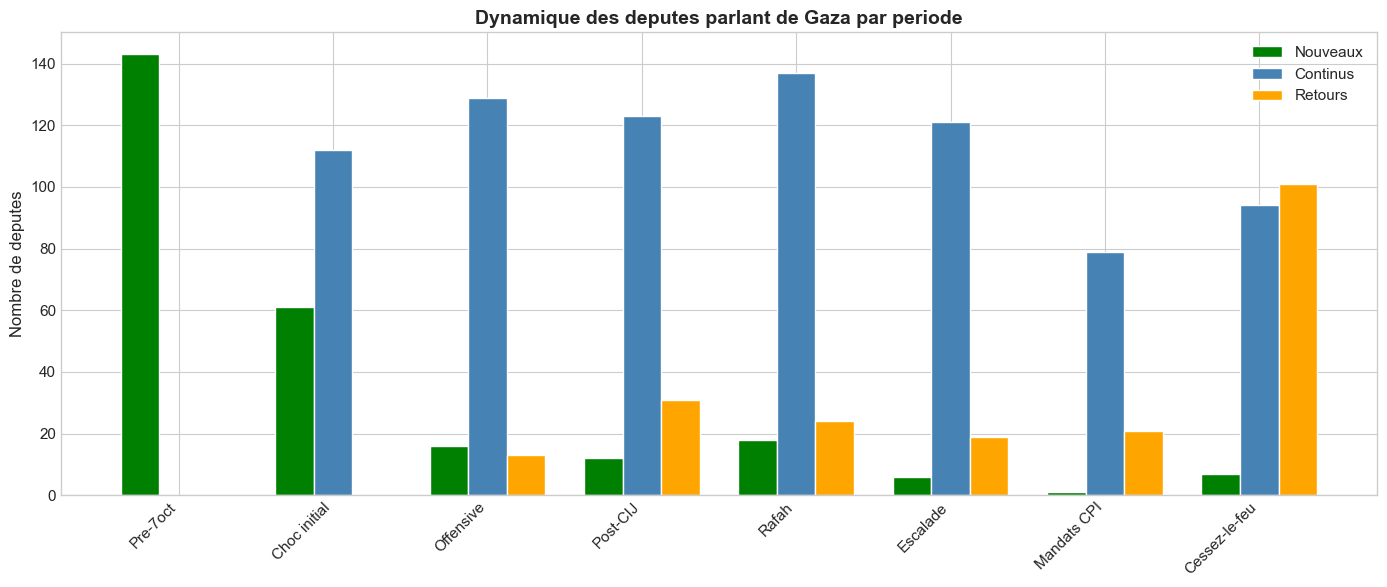


Matrice de transition:
         P0: Pre-7oct  P1: Choc initial  P2: Offensive  P3: Post-CIJ  P4: Rafah  P5: Escalade  P6: Mandats CPI  P7: Cessez-le-feu
Nouveau         143.0              61.0           16.0          12.0       18.0           6.0              1.0                7.0
Continu           0.0             112.0          129.0         123.0      137.0         121.0             79.0               94.0
Retour            0.0               NaN           13.0          31.0       24.0          19.0             21.0              101.0


In [37]:
# Creer une matrice: pour chaque depute, dans quelles periodes il a parle
user_periods = tweets_df.groupby(["username", "period"]).size().unstack(fill_value=0)
user_periods = user_periods.reindex(columns=period_order, fill_value=0)

# Binariser: 1 si a parle, 0 sinon
user_periods_binary = (user_periods > 0).astype(int)

# Calculer les transitions: combien ont parle pour la premiere fois a chaque periode
transitions = pd.DataFrame()
for i, period in enumerate(period_order):
    if i == 0:
        # Premiere periode: tous ceux qui ont parle
        transitions.loc["Nouveau", period] = user_periods_binary[period].sum()
        transitions.loc["Continu", period] = 0
        transitions.loc["Retour", period] = 0
    else:
        prev_periods = period_order[:i]

        # A parle dans une periode precedente
        spoke_before = user_periods_binary[prev_periods].max(axis=1)

        # Nouveau: n'a jamais parle avant
        new_speakers = (spoke_before == 0) & (user_periods_binary[period] == 1)
        transitions.loc["Nouveau", period] = new_speakers.sum()

        # Continu: a parle juste avant
        if i >= 1:
            spoke_prev = user_periods_binary[period_order[i - 1]] == 1
            continues = spoke_prev & (user_periods_binary[period] == 1)
            transitions.loc["Continu", period] = continues.sum()

        # Retour: a parle avant mais pas juste avant
        if i >= 2:
            spoke_earlier = user_periods_binary[prev_periods[:-1]].max(axis=1) == 1
            not_spoke_prev = user_periods_binary[period_order[i - 1]] == 0
            returns = (
                spoke_earlier & not_spoke_prev & (user_periods_binary[period] == 1)
            )
            transitions.loc["Retour", period] = returns.sum()

# Visualiser
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(period_order))
width = 0.25

bars1 = ax.bar(
    x - width, transitions.loc["Nouveau"], width, label="Nouveaux", color="green"
)
bars2 = ax.bar(
    x, transitions.loc["Continu"], width, label="Continus", color="steelblue"
)
bars3 = ax.bar(
    x + width, transitions.loc["Retour"], width, label="Retours", color="orange"
)

ax.set_xticks(x)
ax.set_xticklabels([p.split(": ")[1] for p in period_order], rotation=45, ha="right")
ax.set_title("Dynamique des deputes parlant de Gaza par periode", fontweight="bold")
ax.set_ylabel("Nombre de deputes")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "transitions_deputes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMatrice de transition:")
print(transitions.to_string())

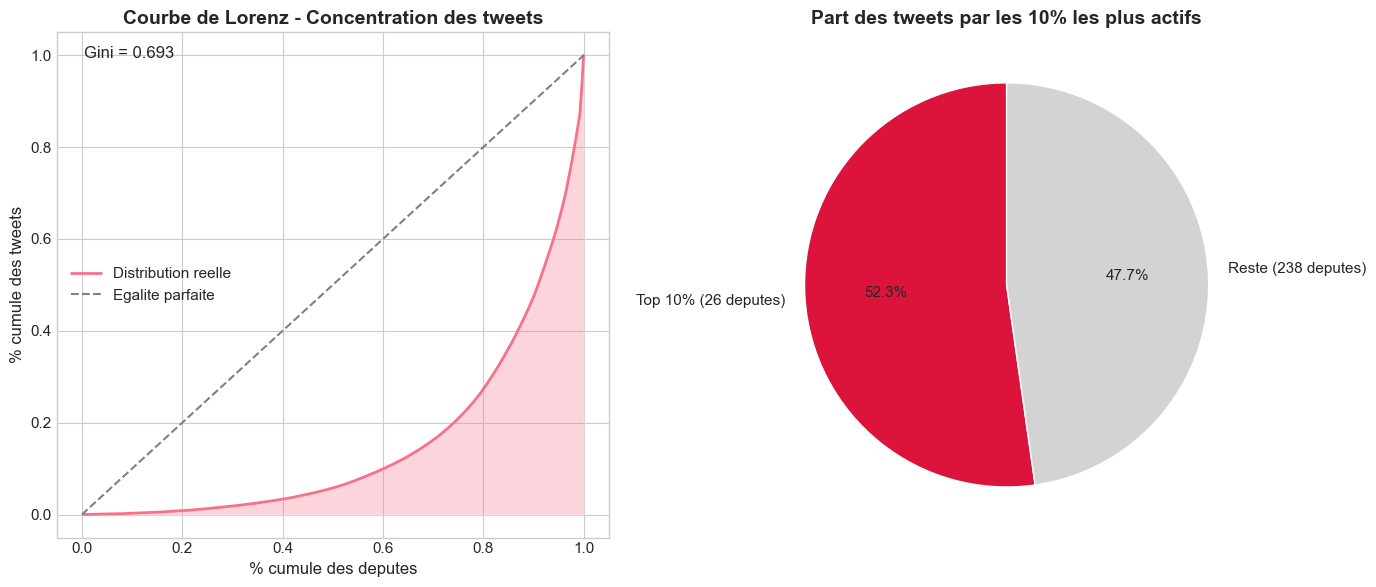


Coefficient de Gini: 0.693
(0 = egalite parfaite, 1 = concentration totale)

Les 26 deputes les plus actifs (10%) produisent 52.3% des tweets


In [38]:
# Analyser si l'activite est concentree sur quelques deputes ou dispersee
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Courbe de Lorenz pour les tweets
user_counts = tweets_df["username"].value_counts().sort_values()
cumul_users = np.arange(1, len(user_counts) + 1) / len(user_counts)
cumul_tweets = user_counts.cumsum() / user_counts.sum()

axes[0].plot(cumul_users, cumul_tweets, linewidth=2, label="Distribution reelle")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Egalite parfaite")
axes[0].fill_between(cumul_users, cumul_tweets, alpha=0.3)
axes[0].set_xlabel("% cumule des deputes")
axes[0].set_ylabel("% cumule des tweets")
axes[0].set_title("Courbe de Lorenz - Concentration des tweets", fontweight="bold")
axes[0].legend()

# Calculer le coefficient de Gini
gini = 1 - 2 * np.trapz(cumul_tweets, cumul_users)
axes[0].text(0.05, 0.95, f"Gini = {gini:.3f}", transform=axes[0].transAxes, fontsize=12)

# Top 10% vs reste
n_top10 = int(len(user_counts) * 0.1)
top10_tweets = user_counts.tail(n_top10).sum()
rest_tweets = user_counts.head(len(user_counts) - n_top10).sum()

axes[1].pie(
    [top10_tweets, rest_tweets],
    labels=[
        f"Top 10% ({n_top10} deputes)",
        f"Reste ({len(user_counts) - n_top10} deputes)",
    ],
    autopct="%1.1f%%",
    colors=["crimson", "lightgray"],
    startangle=90,
)
axes[1].set_title("Part des tweets par les 10% les plus actifs", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "concentration_activite.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCoefficient de Gini: {gini:.3f}")
print(f"(0 = egalite parfaite, 1 = concentration totale)")
print(
    f"\nLes {n_top10} deputes les plus actifs (10%) produisent {top10_tweets/len(tweets_df)*100:.1f}% des tweets"
)

In [39]:
# Analyser si certains groupes utilisent des mots-cles plus diversifies
def get_keyword_diversity(df, col="keyword_matches"):
    """Calcule la diversite des mots-cles (nombre unique / total)."""
    all_kw = []
    for matches in df[col].dropna():
        if isinstance(matches, np.ndarray):
            all_kw.extend(matches.tolist())
        elif isinstance(matches, list):
            all_kw.extend(matches)

    if len(all_kw) == 0:
        return 0, 0, set()

    unique_kw = set(all_kw)
    return len(unique_kw), len(all_kw), unique_kw


# Par groupe
diversity_data = []
for group in tweets_df["groupe_norm"].unique():
    group_df = tweets_df[tweets_df["groupe_norm"] == group]
    unique, total, kw_set = get_keyword_diversity(group_df)

    diversity_data.append(
        {
            "groupe": group,
            "n_tweets": len(group_df),
            "kw_uniques": unique,
            "kw_total": total,
            "ratio": unique / total if total > 0 else 0,
            "top_kw": ", ".join(list(Counter(kw_set).most_common(5)))[:50],
        }
    )

div_df = pd.DataFrame(diversity_data)
div_df = div_df.sort_values("n_tweets", ascending=False)

print("=== DIVERSITE DES MOTS-CLES PAR GROUPE ===")
print(div_df[["groupe", "n_tweets", "kw_uniques", "ratio"]].to_string(index=False))

# Visualiser
fig, ax = plt.subplots(figsize=(12, 6))

div_df_sorted = div_df.sort_values("ratio")
colors = plt.cm.RdYlGn(div_df_sorted["ratio"] / div_df_sorted["ratio"].max())
ax.barh(div_df_sorted["groupe"], div_df_sorted["ratio"], color=colors)
ax.set_xlabel("Ratio diversite (mots-cles uniques / total)")
ax.set_title("Diversite lexicale par groupe politique", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "diversite_lexicale.png", dpi=150, bbox_inches="tight")
plt.show()

TypeError: sequence item 0: expected str instance, tuple found